# 250 mL Scale-Down -- Transfer-Mass (Mixing) Model, Torispherical Head Geometry, and Serialized Transport Asset

**Scope.** Mass-transfer / mixing physics only -- no reaction kinetics
anywhere in this notebook. The 5 L reference data, model structure, and
fitting logic **mimic `5L_tank_transfer_mass_3_compartments.ipynb` directly**
(re-run against the same experimental CSV, not hand-copied): three
compartments (Zone 1 top/feed+probe, Zone 2 impeller zone, Zone 3 lower dead
zone), adjacent-zone-only transport, `Q_1->2` well-determined / `Q_2->3` only
bounded, `V1_initial != V1_final` tracked explicitly, volumetric titrant flow
rate reported at both scales.

**What's new in this revision:**
1. **250 mL geometry is now exact** (measured), not a placeholder:
   `D_tank=7.085 cm`, `D_impeller=5 cm`, `H_impeller=1.123 cm`,
   `H_liquid_initial=7.870 cm`, unbaffled.
2. **Torispherical bottom-head model** for the 250 mL vessel's dished base,
   replacing the flat-cylinder assumption -- crown radius `R`, knuckle radius
   `a`, and exact head volume computed for both the ASME (F&D, 6% knuckle) and
   DIN 28011 (Klopper, 10% knuckle) standards, given `D=7.085 cm` and head
   depth `h=1.123 cm`.
3. **A genuine structural finding falls out of the given numbers**: the
   impeller's nominal swept zone (`h_impeller +/- D_impeller/2`) would extend
   to `z = 1.123 - 2.5 = -1.377 cm` -- *below* the physical vessel base. That
   means the impeller's zone of influence fully engulfs the torispherical
   head; there is no separate quiescent Zone 3 at this scale. The 250 mL
   vessel is therefore modeled as a **2-compartment** system (Zone 1 top,
   Zone 2 = head + impeller swept cylinder merged), while the 5 L reference
   keeps its validated 3-compartment treatment unchanged.
4. All computed geometry, zone volumes, `Q`/`Nq` transport parameters, and
   scale-down criteria are bundled into a `ReactorGeometryModel` object and
   serialized with `dill` to `reactor_geometry_transport.dill`, then reloaded
   in-notebook to confirm the round trip works.

**5 L parent reactor geometry is read/preserved exactly as previously
defined** (Sections 1-4 below, unchanged) -- only the 250 mL vessel and
everything derived from it is updated in this revision.

**No Git staging, committing, or pushing operations are performed by this
notebook or by building it.**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import dill
from scipy.integrate import solve_ivp
from scipy.optimize import least_squares, brentq
from scipy.stats import chi2

## Section 1 -- 5 L reference vessel geometry & 3-zone split (mimics `5L_tank_transfer_mass_3_compartments.ipynb` Cell 1)

Same vessel/impeller/probe geometry, same 160 rpm titration run, same
zone-boundary rule (Zone 2 = one impeller diameter tall, centered on the
impeller -- a structural choice, not fit from data; the two *fit* parameters
are the flow rates, not this boundary). **Preserved unchanged from the prior
revision.**

In [2]:
# --- vessel & liquid geometry (identical to 5L_tank_transfer_mass_3_compartments.ipynb Cell 1) ---
D_IMPELLER_5L_CM = 7.5
D_TANK_5L_CM = 20.5
H_IMPELLER_5L_CM = 8.0            # impeller clearance from tank bottom
H_LIQUID_INITIAL_5L_CM = 17.2     # liquid height BEFORE the titrant feed
A_CROSS_5L_CM2 = np.pi * (D_TANK_5L_CM / 2) ** 2

N_RPM_5L = 160.0                  # this reference run's condition
N_RPS_5L = N_RPM_5L / 60.0

PH_PROBE_HEIGHT_5L_CM = 12.6

# --- HCl titrant feed (continuous, not a pulse) ---
V_HCL_TOTAL_5L_ML = 266.0
PUMP_RATE_5L_ML_MIN = 110.0       # <-- volumetric flow rate of the pH titrant, 5 L scale
T_FEED_END_5L_MIN = V_HCL_TOTAL_5L_ML / PUMP_RATE_5L_ML_MIN
PUMP_RATE_5L_L_MIN = PUMP_RATE_5L_ML_MIN / 1000.0

# --- chemistry ---
C_TRIS_STOCK_M = 0.20000
C_HCL_STOCK_M = 1.0
PKA_TRIS = 8.06

print(f"Volumetric titrant flow rate (5 L): {PUMP_RATE_5L_ML_MIN:.1f} mL/min ({PUMP_RATE_5L_L_MIN:.4f} L/min)")
print(f"Titrant feed duration (5 L)       : {T_FEED_END_5L_MIN:.4f} min ({T_FEED_END_5L_MIN*60:.2f} s)")

# --- 3-zone axial split ---
def zone_boundaries(h_impeller_cm, D_impeller_cm):
    z_lower = h_impeller_cm - D_impeller_cm / 2.0
    z_upper = h_impeller_cm + D_impeller_cm / 2.0
    return z_lower, z_upper

def zone_volumes_L(A_cross_cm2, z_lower_cm, z_upper_cm, h_liquid_initial_cm, V_titrant_total_mL):
    '''Returns (V3_fixed, V2_fixed, V1_initial, V1_final, V_total_initial, V_total_final), all in L.
    V1 (top zone) grows from V1_initial to V1_final as the titrant is added -- starting volume
    is NOT the final volume, tracked explicitly throughout this notebook.'''
    V3 = (A_cross_cm2 * z_lower_cm) / 1000.0
    V2 = (A_cross_cm2 * (z_upper_cm - z_lower_cm)) / 1000.0
    V1_initial = (A_cross_cm2 * (h_liquid_initial_cm - z_upper_cm)) / 1000.0
    V1_final = V1_initial + V_titrant_total_mL / 1000.0
    V_total_initial = V3 + V2 + V1_initial
    V_total_final = V3 + V2 + V1_final
    return V3, V2, V1_initial, V1_final, V_total_initial, V_total_final

z2_lower_5L, z2_upper_5L = zone_boundaries(H_IMPELLER_5L_CM, D_IMPELLER_5L_CM)
V3_5L, V2_5L, V1_initial_5L, V1_final_5L, V_total_initial_5L, V_total_final_5L = zone_volumes_L(
    A_CROSS_5L_CM2, z2_lower_5L, z2_upper_5L, H_LIQUID_INITIAL_5L_CM, V_HCL_TOTAL_5L_ML)

print(f"\nZone 3 (lower bulk)      : 0.00 - {z2_lower_5L:.2f} cm  ->  V3 = {V3_5L:.3f} L (fixed)")
print(f"Zone 2 (impeller zone)   : {z2_lower_5L:.2f} - {z2_upper_5L:.2f} cm  ->  V2 = {V2_5L:.3f} L (fixed)")
print(f"Zone 1 (top, feed+probe) : {z2_upper_5L:.2f} - {H_LIQUID_INITIAL_5L_CM:.2f} cm (initial)")
print(f"  V1_initial (BEFORE titrant feed) = {V1_initial_5L:.3f} L")
print(f"  V1_final   (AFTER titrant feed)  = {V1_final_5L:.3f} L   <-- starting != final volume")
print(f"V_total_initial = {V_total_initial_5L:.3f} L   |   V_total_final = {V_total_final_5L:.3f} L")
print(f"N (rotation speed) = {N_RPS_5L:.4f} rev/s ({N_RPM_5L:.0f} RPM)")

Volumetric titrant flow rate (5 L): 110.0 mL/min (0.1100 L/min)
Titrant feed duration (5 L)       : 2.4182 min (145.09 s)

Zone 3 (lower bulk)      : 0.00 - 4.25 cm  ->  V3 = 1.403 L (fixed)
Zone 2 (impeller zone)   : 4.25 - 11.75 cm  ->  V2 = 2.475 L (fixed)
Zone 1 (top, feed+probe) : 11.75 - 17.20 cm (initial)
  V1_initial (BEFORE titrant feed) = 1.799 L
  V1_final   (AFTER titrant feed)  = 2.065 L   <-- starting != final volume
V_total_initial = 5.677 L   |   V_total_final = 5.943 L
N (rotation speed) = 2.6667 rev/s (160 RPM)


## Section 2 -- 3-compartment forward model + joint fit of `Q_1->2`, `Q_2->3` (re-run against the real 5 L CSV)

Identical model and fitting method to `5L_tank_transfer_mass_3_compartments.ipynb`:
`Q_1->2` (fast, impeller-driven, Zone1<->Zone2) and `Q_2->3` (slow,
Zone2<->Zone3) fit jointly via `least_squares` against the measured `pH(t)`.
**Preserved unchanged.**

In [3]:
def V1_of_t(t_min, V1_initial_L, feed_L_min, t_feed_end_min):
    added = feed_L_min * min(t_min, t_feed_end_min)
    return V1_initial_L + added

def feed_rate_mol_min(t_min, feed_L_min, t_feed_end_min, C_HCl_M):
    if t_min <= t_feed_end_min:
        return feed_L_min * C_HCl_M
    return 0.0

def simulate_ph_3zone(Q12_L_min, Q23_L_min, t_eval_min, pH0,
                       V1_initial_L, V2_L, V3_L, feed_L_min, t_feed_end_min,
                       C_Tris_M=C_TRIS_STOCK_M, C_HCl_M=C_HCL_STOCK_M, pKa=PKA_TRIS):
    '''Simulate Zone-1 (probe) pH(t) for given inter-zone flows. pH0 sets the initial
    protonation fraction, applied uniformly across all 3 zones, via inverse Henderson-Hasselbalch.'''
    ratio0 = 10 ** (pH0 - pKa)
    frac_TrisH_0 = 1.0 / (1.0 + ratio0)

    n_Tris_1_0 = (1 - frac_TrisH_0) * C_Tris_M * V1_initial_L
    n_TrisH_1_0 = frac_TrisH_0 * C_Tris_M * V1_initial_L
    n_Tris_2_0 = (1 - frac_TrisH_0) * C_Tris_M * V2_L
    n_TrisH_2_0 = frac_TrisH_0 * C_Tris_M * V2_L
    n_Tris_3_0 = (1 - frac_TrisH_0) * C_Tris_M * V3_L
    n_TrisH_3_0 = frac_TrisH_0 * C_Tris_M * V3_L
    y0 = [n_Tris_1_0, n_TrisH_1_0, n_Tris_2_0, n_TrisH_2_0, n_Tris_3_0, n_TrisH_3_0]

    def ode(t_min, y):
        n_Tris_1, n_TrisH_1, n_Tris_2, n_TrisH_2, n_Tris_3, n_TrisH_3 = np.maximum(y, 0.0)
        V1 = V1_of_t(t_min, V1_initial_L, feed_L_min, t_feed_end_min)
        C_Tris_1, C_TrisH_1 = n_Tris_1 / V1, n_TrisH_1 / V1
        C_Tris_2, C_TrisH_2 = n_Tris_2 / V2_L, n_TrisH_2 / V2_L
        C_Tris_3, C_TrisH_3 = n_Tris_3 / V3_L, n_TrisH_3 / V3_L

        exch12_Tris = Q12_L_min * (C_Tris_1 - C_Tris_2)
        exch12_TrisH = Q12_L_min * (C_TrisH_1 - C_TrisH_2)
        exch23_Tris = Q23_L_min * (C_Tris_2 - C_Tris_3)
        exch23_TrisH = Q23_L_min * (C_TrisH_2 - C_TrisH_3)
        h_feed = feed_rate_mol_min(t_min, feed_L_min, t_feed_end_min, C_HCl_M)

        return [-exch12_Tris - h_feed, -exch12_TrisH + h_feed,
                +exch12_Tris - exch23_Tris, +exch12_TrisH - exch23_TrisH,
                +exch23_Tris, +exch23_TrisH]

    t_end = t_eval_min[-1]
    if t_end <= t_feed_end_min:
        sol = solve_ivp(ode, (0, t_end), y0, t_eval=t_eval_min, method='BDF', rtol=1e-7, atol=1e-10)
        Y = sol.y
    else:
        mask1 = t_eval_min <= t_feed_end_min
        t1 = np.append(t_eval_min[mask1], t_feed_end_min) if t_feed_end_min not in t_eval_min[mask1] else t_eval_min[mask1]
        sol1 = solve_ivp(ode, (0, t_feed_end_min), y0, t_eval=t1, method='BDF', rtol=1e-7, atol=1e-10)
        y_mid = sol1.y[:, -1]
        t2 = t_eval_min[~mask1]
        sol2 = solve_ivp(ode, (t_feed_end_min, t_end), y_mid, t_eval=t2, method='BDF', rtol=1e-7, atol=1e-10)
        Y = np.hstack([sol1.y[:, :len(t_eval_min[mask1])], sol2.y])

    n_Tris_1, n_TrisH_1 = Y[0], Y[1]
    V1_series = np.array([V1_of_t(tm, V1_initial_L, feed_L_min, t_feed_end_min) for tm in t_eval_min])
    C_Tris_1 = np.maximum(n_Tris_1, 1e-12) / V1_series
    C_TrisH_1 = np.maximum(n_TrisH_1, 1e-12) / V1_series
    return pKa + np.log10(C_Tris_1 / C_TrisH_1)


def fit_3zone_transport(csv_path, V1_initial_L, V2_L, V3_L, feed_L_min, t_feed_end_min,
                         D_impeller_m, N_rps, Nq_max_literature=1.0,
                         Q12_0=None, Q23_0=None, robustness_seeds=(0.5, 5.0, 50.0, 500.0, 5000.0)):
    '''Generic joint fit of (Q12, Q23) to a measured (t_sec, pH) CSV -- same method as
    5L_tank_transfer_mass_3_compartments.ipynb: joint least_squares, Jacobian rank check,
    profile-likelihood stderr for Q12, multi-seed robustness + 95% lower bound for Q23,
    and a physically-motivated ceiling refit (Q23 cannot exceed Nq_max_literature).'''
    df_exp = pd.read_csv(csv_path, usecols=[0, 1])
    df_exp.columns = ['t_sec', 'pH']
    t_seconds = df_exp['t_sec'].to_numpy(dtype=float)
    pH_measured = df_exp['pH'].to_numpy(dtype=float)

    V_total_L = V1_initial_L + V2_L + V3_L
    if Q12_0 is None:
        Q12_0 = V_total_L * 3.0
    if Q23_0 is None:
        Q23_0 = V_total_L * 0.05

    def residuals(params, t_sec_arr, pH_arr):
        Q12, Q23 = params
        pH_sim = simulate_ph_3zone(Q12, Q23, t_sec_arr / 60.0, pH_arr[0],
                                    V1_initial_L, V2_L, V3_L, feed_L_min, t_feed_end_min)
        return pH_sim - pH_arr

    fit_result = least_squares(residuals, x0=[Q12_0, Q23_0], args=(t_seconds, pH_measured),
                                bounds=([1e-3, 1e-4], [1e4, 1e4]), method='trf', xtol=1e-12, ftol=1e-12)
    Q12_fit, Q23_fit = fit_result.x

    J = fit_result.jac
    _, S_svd, _ = np.linalg.svd(J, full_matrices=False)
    cond_number = S_svd[0] / S_svd[-1]

    def resid_Q12_only(p):
        return residuals([p[0], Q23_fit], t_seconds, pH_measured)
    prof_Q12 = least_squares(resid_Q12_only, x0=[Q12_fit], bounds=([1e-3], [1e4]), xtol=1e-13, ftol=1e-13)
    J_prof = prof_Q12.jac
    var_Q12 = (2 * prof_Q12.cost / max(1, len(prof_Q12.fun) - 1)) / (J_prof[:, 0] @ J_prof[:, 0])
    Q12_stderr = np.sqrt(var_Q12)

    n_pts, n_params = len(pH_measured), 2
    sigma2 = 2.0 * fit_result.cost / (n_pts - n_params)
    cost_threshold_95 = fit_result.cost + 0.5 * chi2.ppf(0.95, df=1) * sigma2

    def profile_cost_Q23(Q23_fixed):
        def resid_at_fixed_Q23(p):
            return residuals([p[0], Q23_fixed], t_seconds, pH_measured)
        rp = least_squares(resid_at_fixed_Q23, x0=[Q12_fit], bounds=([1e-3], [1e3]), xtol=1e-13, ftol=1e-13)
        return rp.cost - cost_threshold_95

    Q23_lower_95 = brentq(profile_cost_Q23, 1.0, Q23_fit, xtol=0.01)

    multistart_Q12, multistart_Q23 = [], []
    for seed in robustness_seeds:
        r = least_squares(residuals, x0=[Q12_0, seed], args=(t_seconds, pH_measured),
                           bounds=([1e-3, 1e-4], [1e4, 1e4]), method='trf', xtol=1e-12, ftol=1e-12)
        multistart_Q12.append(r.x[0])
        multistart_Q23.append(r.x[1])

    Q_physical_ceiling = Nq_max_literature * N_rps * D_impeller_m ** 3 * 1000.0 * 60.0
    fit_c = least_squares(residuals, x0=[Q12_0, Q23_0], args=(t_seconds, pH_measured),
                           bounds=([1e-3, 1e-4], [1e4, Q_physical_ceiling]), method='trf', xtol=1e-12, ftol=1e-12)
    Q12_fit_c, Q23_fit_c = fit_c.x

    Nq_12 = (Q12_fit / 1000.0 / 60.0) / (N_rps * D_impeller_m ** 3)
    Nq_23_lower = (Q23_lower_95 / 1000.0 / 60.0) / (N_rps * D_impeller_m ** 3)

    return dict(t_seconds=t_seconds, pH_measured=pH_measured,
                Q12_fit=Q12_fit, Q12_stderr=Q12_stderr, Q23_fit_unconstrained=Q23_fit,
                Q23_lower_95=Q23_lower_95, Q_physical_ceiling=Q_physical_ceiling,
                Q12_fit_c=Q12_fit_c, Q23_fit_c=Q23_fit_c,
                Nq_12=Nq_12, Nq_23_lower=Nq_23_lower, Nq_max_literature=Nq_max_literature,
                cond_number=cond_number, cost=fit_result.cost,
                rmse=np.sqrt(np.mean(fit_result.fun ** 2)),
                multistart_Q12_range=(min(multistart_Q12), max(multistart_Q12)),
                multistart_Q23_range=(min(multistart_Q23), max(multistart_Q23)))


D_IMPELLER_5L_M = D_IMPELLER_5L_CM / 100.0
CSV_5L_PATH = 'pH adjustment Exp - Exp2_09072026.csv'
fit_5L = fit_3zone_transport(CSV_5L_PATH, V1_initial_5L, V2_5L, V3_5L,
                              PUMP_RATE_5L_L_MIN, T_FEED_END_5L_MIN,
                              D_IMPELLER_5L_M, N_RPS_5L)

print("=" * 74)
print("  5 L REFERENCE -- 3-COMPARTMENT FIT (160 RPM titration run)")
print("=" * 74)
print(f"  Jacobian condition number : {fit_5L['cond_number']:.3e} "
      f"({'RANK-DEFICIENT' if fit_5L['cond_number'] > 1e6 else 'well-conditioned'})")
print(f"  Q_1->2 (well-determined)  : {fit_5L['Q12_fit']:.4f} +/- {fit_5L['Q12_stderr']:.4f} L/min")
print(f"    multi-seed range        : {fit_5L['multistart_Q12_range'][0]:.3f} - {fit_5L['multistart_Q12_range'][1]:.3f} L/min (reproducible)")
print(f"  Q_2->3 (NOT point-identifiable):")
print(f"    95% CI lower bound      : {fit_5L['Q23_lower_95']:.2f} L/min")
print(f"    physical ceiling (Nq<={fit_5L['Nq_max_literature']}) : {fit_5L['Q_physical_ceiling']:.2f} L/min")
print(f"    multi-seed range        : {fit_5L['multistart_Q23_range'][0]:.0f} - {fit_5L['multistart_Q23_range'][1]:.0f} L/min (NOT reproducible -- confirms non-identifiability)")
print(f"  Nq (from Q_1->2)          : {fit_5L['Nq_12']:.4f}")
print(f"  Nq (from Q_2->3's 95% lower bound; no upper Nq exists): > {fit_5L['Nq_23_lower']:.4f}")
print(f"  RMSE                      : {fit_5L['rmse']:.5f} pH units")

  5 L REFERENCE -- 3-COMPARTMENT FIT (160 RPM titration run)
  Jacobian condition number : 1.489e+08 (RANK-DEFICIENT)
  Q_1->2 (well-determined)  : 8.3538 +/- 0.4216 L/min
    multi-seed range        : 8.352 - 8.355 L/min (reproducible)
  Q_2->3 (NOT point-identifiable):
    95% CI lower bound      : 10.75 L/min
    physical ceiling (Nq<=1.0) : 67.50 L/min
    multi-seed range        : 2015 - 4765 L/min (NOT reproducible -- confirms non-identifiability)
  Nq (from Q_1->2)          : 0.1238
  Nq (from Q_2->3's 95% lower bound; no upper Nq exists): > 0.1593
  RMSE                      : 0.06496 pH units


## Section 3 -- Transport-matrix eigenvalue timescales (fast/slow), 5 L reference

Same diagnostic as the reference notebook's Cell 3e: the two non-zero
eigenvalues of the post-feed-end linear transport matrix give the fast
(Zone1<->Zone2) and slow (Zone2<->Zone3) relaxation timescales directly from
`Q_1->2`, `Q_2->3`, and the (now-fixed, post-feed) volumes -- not fit to data.
**Preserved unchanged.**

In [4]:
def transport_eigs_per_min(V1_post_feed_L, V2_L, V3_L, Q12, Q23):
    '''Returns (slow_rate, fast_rate), both positive, per minute.'''
    Am = np.array([
        [-Q12 / V1_post_feed_L,  Q12 / V2_L,                        0],
        [ Q12 / V1_post_feed_L, -(Q12 / V2_L + Q23 / V2_L),  Q23 / V3_L],
        [0,                      Q23 / V2_L,                -Q23 / V3_L],
    ])
    eigs = np.sort(np.linalg.eigvals(Am).real)
    return -eigs[1], -eigs[0]   # (slow_rate, fast_rate), per minute

slow_5L, fast_5L = transport_eigs_per_min(V1_final_5L, V2_5L, V3_5L, fit_5L['Q12_fit'], fit_5L['Q_physical_ceiling'])
print(f"5 L reference timescales (Q_2->3 at physical ceiling, the best available single-number proxy):")
print(f"  fast tau (Zone1<->Zone2) = {1/fast_5L*60:.2f} s")
print(f"  slow tau (Zone2<->Zone3) = {1/slow_5L*60:.2f} s")

5 L reference timescales (Q_2->3 at physical ceiling, the best available single-number proxy):
  fast tau (Zone1<->Zone2) = 0.78 s
  slow tau (Zone2<->Zone3) = 9.85 s


## Section 4 -- 5 L summary: Nq and Q at both flow scales (impeller-driven vs. secondary)

Explicit answer to "provide Nq and Q values" for the 5 L reference, before
scaling down. **Preserved unchanged.**

In [5]:
Q23_lower_str = '>' + format(fit_5L['Q23_lower_95'], '.2f')
Nq23_lower_str = '>' + format(fit_5L['Nq_23_lower'], '.4f')

print(f"{'Flow':<10}{'Q (L/min)':>16}{'Nq':>12}{'Status':>28}")
print('-' * 66)
print(f"{'Q_1->2':<10}{fit_5L['Q12_fit']:>16.4f}{fit_5L['Nq_12']:>12.4f}{'point value, well-determined':>28}")
print(f"{'Q_2->3':<10}{Q23_lower_str:>16}{Nq23_lower_str:>12}{'lower bound only':>28}")
print(f"{'Q_2->3':<10}{fit_5L['Q_physical_ceiling']:>16.2f}{fit_5L['Nq_max_literature']:>12.4f}{'physical ceiling (not a fit)':>28}")

Flow             Q (L/min)          Nq                      Status
------------------------------------------------------------------
Q_1->2              8.3538      0.1238point value, well-determined
Q_2->3              >10.75     >0.1593            lower bound only
Q_2->3               67.50      1.0000physical ceiling (not a fit)


## Section 4b -- 5 L mixing time (theta_95)

Added metric (Phase 4 asks for `theta_95` at "both scale conditions"). For a
linear system, the slowest eigenmode dominates the long-time approach to
homogeneity: `theta_95 = ln(20) / slow_rate` (time to close to within 5% of
the fully-mixed state).

In [6]:
theta95_5L_min = np.log(20.0) / slow_5L
print(f"5 L reference theta_95 (95% mixing time, Q_2->3 at physical ceiling) = {theta95_5L_min:.3f} min "
      f"({theta95_5L_min*60:.1f} s)")

5 L reference theta_95 (95% mixing time, Q_2->3 at physical ceiling) = 0.492 min (29.5 s)


## Section 5 -- 250 mL vessel geometry **(EXACT -- measured, no longer a placeholder)**

Updated per the confirmed specification. `NQ_MAX_LITERATURE_250` is set to
the same literature-anchored ceiling used for the 5 L reference's `Q_2->3`
characterization (`Nq<=1.0`).

**2026-07-20 -- investigation log:** a `Nq<=2.5` exploratory relaxation was
tried and reverted -- widening the ceiling did not settle to an interior
optimum (the fit just re-pinned at the new edge with a shrinking cost gap),
confirming the mismatch is not a mixing-rate identifiability problem. Back
to the literature-anchored `Nq<=1.0` ceiling while the actual cause is
chased down via Section 12's mass-balance cross-check: `C_HCL_STOCK_M` and
the HCl delivery (13.75 mL delivered within 145 s) have since been
**confirmed correct**; `C_TRIS_STOCK_M` is under active investigation.

In [7]:
# =====================================================================
# 250 mL VESSEL GEOMETRY -- CONFIRMED / MEASURED (no longer a placeholder)
# =====================================================================
GEOMETRY_IS_PLACEHOLDER = False    # confirmed measured values below

D_TANK_250_CM           = 7.085
D_IMPELLER_250_CM       = 5.0
H_IMPELLER_250_CM       = 1.123     # impeller clearance from tank bottom
H_LIQUID_INITIAL_250_CM = 7.870     # liquid height BEFORE titrant feed
BAFFLED_250             = False
NQ_MAX_LITERATURE_250   = 1.0     # literature-anchored ceiling (2026-07-20: 2.5 exploratory relaxation reverted, see Section 5 markdown)

D_IMPELLER_250_M = D_IMPELLER_250_CM / 100.0
A_CROSS_250_CM2 = np.pi * (D_TANK_250_CM / 2) ** 2

print(f"250 mL geometry (confirmed measured values):")
print(f"  D_tank           = {D_TANK_250_CM:.3f} cm")
print(f"  D_impeller       = {D_IMPELLER_250_CM:.3f} cm")
print(f"  H_impeller       = {H_IMPELLER_250_CM:.3f} cm (clearance from tank bottom)")
print(f"  H_liquid_initial = {H_LIQUID_INITIAL_250_CM:.3f} cm (before titrant feed)")
print(f"  Baffled          = {BAFFLED_250}")
print(f"  A_cross          = {A_CROSS_250_CM2:.3f} cm^2")
print(f"  Impeller/tank diameter ratio = {D_IMPELLER_250_CM/D_TANK_250_CM:.3f} "
      f"(5 L reference ratio: {D_IMPELLER_5L_CM/D_TANK_5L_CM:.3f} -- this vessel's impeller is proportionally much larger)")

250 mL geometry (confirmed measured values):
  D_tank           = 7.085 cm
  D_impeller       = 5.000 cm
  H_impeller       = 1.123 cm (clearance from tank bottom)
  H_liquid_initial = 7.870 cm (before titrant feed)
  Baffled          = False
  A_cross          = 39.425 cm^2
  Impeller/tank diameter ratio = 0.706 (5 L reference ratio: 0.366 -- this vessel's impeller is proportionally much larger)


## Section 6 -- Phase 1: Torispherical head geometry refinement

Exact torispherical (dished) head volume, following the standard closed-form
solution (crown radius `R`, knuckle radius `a`, `c = D/2 - a`):

$$V_{head} = \frac{\pi}{3}\Big[2hR^2-(2a^2+c^2+2aR)(R-h)+3a^2c\,\sin^{-1}\frac{R-h}{R-a}\Big]$$

with the head-depth constraint `h = R - sqrt((R-a)^2 - (D/2-a)^2)` relating
`R`, `a`, `D`, and `h`. Given the **measured** `D=7.085 cm` and
`h=1.123 cm` (the impeller-baseline/knuckle coordinate boundary), `R` is
solved for under each standard's fixed knuckle ratio:

- **ASME** (Flanged & Dished, "6% knuckle"): `R = D`, `a = 0.06D` (as a
  *starting* ratio -- `R` here is *solved*, not assumed, from the given `h`).
- **DIN 28011** (Klopper): `a = 0.10D`.

Reference: [Torispherical Head Volume and Weight Calculation
(Kezar Engineering)](https://kezareng.com/articles/torispherical-head-volume-and-weight).

In [8]:
def solve_R_from_D_h_a(D_cm, h_cm, a_cm):
    '''Solve for crown radius R given D, target head depth h, and knuckle radius a,
    from h = R - sqrt((R-a)^2 - (D/2-a)^2). Returns (R, c) with c = D/2 - a.'''
    c = D_cm / 2.0 - a_cm
    numerator = a_cm ** 2 - h_cm ** 2 - c ** 2
    denominator = 2.0 * (a_cm - h_cm)
    R = numerator / denominator
    return R, c

def torispherical_head_volume_cm3(R_cm, a_cm, c_cm, h_cm):
    '''Exact internal volume (cm^3 = mL) of a torispherical head, apex to tangent line.'''
    term1 = 2.0 * h_cm * R_cm ** 2
    term2 = (2.0 * a_cm ** 2 + c_cm ** 2 + 2.0 * a_cm * R_cm) * (R_cm - h_cm)
    term3 = 3.0 * a_cm ** 2 * c_cm * np.arcsin((R_cm - h_cm) / (R_cm - a_cm))
    return (np.pi / 3.0) * (term1 - term2 + term3)

def head_depth_from_R_a(R_cm, a_cm, D_cm):
    '''Inverse check: given R, a, D, what head depth h does that imply?'''
    c = D_cm / 2.0 - a_cm
    return R_cm - np.sqrt((R_cm - a_cm) ** 2 - c ** 2)

TORISPHERICAL_STANDARDS = {'ASME': 0.06, 'DIN': 0.10}   # knuckle radius as fraction of D

def torispherical_report(D_cm, h_cm, standards=TORISPHERICAL_STANDARDS):
    rows = {}
    for name, a_ratio in standards.items():
        a = a_ratio * D_cm
        R, c = solve_R_from_D_h_a(D_cm, h_cm, a)
        V_head = torispherical_head_volume_cm3(R, a, c, h_cm)
        h_check = head_depth_from_R_a(R, a, D_cm)
        rows[name] = dict(a=a, R=R, c=c, h=h_cm, V_head_mL=V_head, h_check=h_check)
    return rows

torispherical_250 = torispherical_report(D_TANK_250_CM, H_IMPELLER_250_CM)

print("=" * 82)
print("  250 mL BOTTOM HEAD -- TORISPHERICAL GEOMETRY, ASME vs DIN")
print(f"  (D = {D_TANK_250_CM} cm, h = {H_IMPELLER_250_CM} cm)")
print("=" * 82)
print(f"{'Standard':<10}{'a (cm)':>10}{'R (cm)':>10}{'c (cm)':>10}{'V_head (mL)':>14}{'h check':>10}")
print('-' * 64)
for name, row in torispherical_250.items():
    print(f"{name:<10}{row['a']:>10.4f}{row['R']:>10.4f}{row['c']:>10.4f}{row['V_head_mL']:>14.4f}{row['h_check']:>10.6f}")

TORISPHERICAL_STANDARD_250 = 'ASME'   # selected operating standard for downstream compartment volumes
V_head_250_selected = torispherical_250[TORISPHERICAL_STANDARD_250]['V_head_mL']
print(f"\nSelected standard for downstream use: {TORISPHERICAL_STANDARD_250} "
      f"(V_head = {V_head_250_selected:.4f} mL)")

# --- contrast against the 5 L reference's existing (flat-cylinder) Zone-3 model ---
# 5 L geometry/Zone-3 boundary are PRESERVED unchanged above; this is an informational
# comparison only -- it does NOT alter V3_5L used elsewhere in this notebook.
torispherical_5L_contrast = torispherical_report(D_TANK_5L_CM, z2_lower_5L)
print(f"\nContrast vs. 5 L reference's existing flat-bottom Zone-3 model "
      f"(D={D_TANK_5L_CM} cm, h=z2_lower={z2_lower_5L:.2f} cm; 5 L geometry itself is unchanged):")
print(f"  Current flat-cylinder Zone 3 volume : {V3_5L*1000:.2f} mL")
for name, row in torispherical_5L_contrast.items():
    delta = row['V_head_mL'] - V3_5L * 1000.0
    print(f"  {name} torispherical equivalent      : {row['V_head_mL']:.2f} mL "
          f"(delta = {delta:+.2f} mL, {delta/(V3_5L*1000.0)*100:+.1f}%)")

  250 mL BOTTOM HEAD -- TORISPHERICAL GEOMETRY, ASME vs DIN
  (D = 7.085 cm, h = 1.123 cm)
Standard      a (cm)    R (cm)    c (cm)   V_head (mL)   h check
----------------------------------------------------------------
ASME          0.4251    7.7365    3.1174       27.4144  1.123000
DIN           0.7085   10.6040    2.8340       31.3001  1.123000

Selected standard for downstream use: ASME (V_head = 27.4144 mL)

Contrast vs. 5 L reference's existing flat-bottom Zone-3 model (D=20.5 cm, h=z2_lower=4.25 cm; 5 L geometry itself is unchanged):
  Current flat-cylinder Zone 3 volume : 1402.77 mL
  ASME torispherical equivalent      : 822.26 mL (delta = -580.51 mL, -41.4%)
  DIN torispherical equivalent      : 891.59 mL (delta = -511.18 mL, -36.4%)


## Section 7 -- Phase 2: Compartment discretization for 250 mL, using the updated head profile

Applying the *same* zone-boundary rule as the 5 L reference (impeller zone =
one impeller diameter tall, centered on the impeller) to the 250 mL geometry
produces a **negative** lower boundary:

`z2_lower = H_impeller - D_impeller/2 = 1.123 - 2.5 = -1.377 cm`

This is not a numerical error -- it is a real consequence of this vessel's
unusually large impeller-to-tank diameter ratio (0.706 vs. 0.366 at 5 L). It
means the impeller's nominal swept envelope extends *below the physical
vessel base*, i.e. **the impeller's zone of influence fully engulfs the
torispherical head**. There is no separate quiescent Zone 3 at this scale.

**Consequence:** the 250 mL vessel is dynamically mapped to a **2-compartment**
system: Zone 2 becomes "head + impeller-swept cylinder" (volume = exact
torispherical head volume + the remaining straight-cylinder portion up to
`z2_upper`), and Zone 3 is dropped (volume 0). Zone 1 (top) is unchanged in
form. This is analogous in spirit to the reference notebook's own finding
that `Q_2->3` isn't a well-posed point value -- here the compartment
structure itself, not just one flow rate, degenerates at this scale.

In [9]:
z2_lower_naive_250 = H_IMPELLER_250_CM - D_IMPELLER_250_CM / 2.0
z2_upper_250 = H_IMPELLER_250_CM + D_IMPELLER_250_CM / 2.0

print(f"z2_lower (naive, symmetric-swept-zone rule) = {z2_lower_naive_250:.4f} cm")
print(f"z2_upper                                    = {z2_upper_250:.4f} cm")

ZONE3_DEGENERATE_250 = z2_lower_naive_250 <= 0.0

if ZONE3_DEGENERATE_250:
    print("\n-> DEGENERATE: z2_lower < 0 -- impeller swept zone engulfs the entire torispherical head.")
    print("   Zone 3 has zero volume; 250 mL is modeled as a 2-compartment system (Zone 1 / Zone 2).")
    V3_250 = 0.0
    V2_250 = V_head_250_selected + A_CROSS_250_CM2 * (z2_upper_250 - H_IMPELLER_250_CM)
    z2_lower_250_effective = 0.0
else:
    # Not triggered by this vessel's given numbers; retained for completeness/generality.
    # Would require a partial (0 -> z2_lower) torispherical integral for full precision --
    # flagged here as a documented limitation rather than silently approximated.
    print("\n-> z2_lower >= 0: classical 3-zone split applies; using flat-cylinder Zone 3 "
          "(a partial torispherical integral would be more precise but is not needed here).")
    V3_250 = A_CROSS_250_CM2 * z2_lower_naive_250 / 1000.0
    V2_250 = A_CROSS_250_CM2 * (z2_upper_250 - z2_lower_naive_250) / 1000.0
    z2_lower_250_effective = z2_lower_naive_250

if ZONE3_DEGENERATE_250:
    V2_250 = V2_250 / 1000.0   # cm^3 (mL) -> L

V1_initial_250 = A_CROSS_250_CM2 * (H_LIQUID_INITIAL_250_CM - z2_upper_250) / 1000.0
V_total_initial_250 = V3_250 + V2_250 + V1_initial_250

print(f"\nZone 3 (dead zone)       : volume = {V3_250*1000:.4f} mL (degenerate -> 0)" if ZONE3_DEGENERATE_250
      else f"\nZone 3 (dead zone)       : 0.00 - {z2_lower_250_effective:.2f} cm -> V3 = {V3_250*1000:.4f} mL")
print(f"Zone 2 (impeller + head) : {z2_lower_250_effective:.2f} - {z2_upper_250:.2f} cm "
      f"(curved head {H_IMPELLER_250_CM:.3f} cm + straight cylinder {z2_upper_250-H_IMPELLER_250_CM:.3f} cm) "
      f"-> V2 = {V2_250*1000:.4f} mL")
print(f"Zone 1 (top, feed+probe) : {z2_upper_250:.2f} - {H_LIQUID_INITIAL_250_CM:.2f} cm (initial) "
      f"-> V1_initial = {V1_initial_250*1000:.4f} mL")
print(f"V_total_initial (computed from geometry) = {V_total_initial_250*1000:.2f} mL "
      f"(nominal vessel label: ~250 mL)")

# consistency check: head+cylinder shortcut should equal the zone sum exactly (both in mL/cm^3 here)
V_total_shortcut_mL = V_head_250_selected + A_CROSS_250_CM2 * (H_LIQUID_INITIAL_250_CM - H_IMPELLER_250_CM)
print(f"Consistency check (head + full straight cylinder above tangent line): {V_total_shortcut_mL:.2f} mL "
      f"(should match V_total_initial above)")

z2_lower (naive, symmetric-swept-zone rule) = -1.3770 cm
z2_upper                                    = 3.6230 cm

-> DEGENERATE: z2_lower < 0 -- impeller swept zone engulfs the entire torispherical head.
   Zone 3 has zero volume; 250 mL is modeled as a 2-compartment system (Zone 1 / Zone 2).

Zone 3 (dead zone)       : volume = 0.0000 mL (degenerate -> 0)
Zone 2 (impeller + head) : 0.00 - 3.62 cm (curved head 1.123 cm + straight cylinder 2.500 cm) -> V2 = 125.9764 mL
Zone 1 (top, feed+probe) : 3.62 - 7.87 cm (initial) -> V1_initial = 167.4372 mL
V_total_initial (computed from geometry) = 293.41 mL (nominal vessel label: ~250 mL)
Consistency check (head + full straight cylinder above tangent line): 293.41 mL (should match V_total_initial above)


## Section 8 -- Phase 3: Mass-transfer parameter extraction for 250 mL

`Q_1->2`/`Nq_12` carried over from the 5 L fit (Section 2), evaluated at the
default constant-N (160 rpm) criterion. **`Q_2->3` does not apply** at this
scale -- there is no Zone 3 to exchange with (Section 7's finding). Only one
flow rate governs mixing here, so `tau_mix`/`theta_95` use the simple
2-compartment formula, not the 3-zone eigenvalue system.

In [10]:
N_RPM_250_DEFAULT = N_RPM_5L        # constant-N carryover, the default operating point
N_RPS_250_DEFAULT = N_RPM_250_DEFAULT / 60.0

Q12_250_PREDICTED = fit_5L['Nq_12'] * N_RPS_250_DEFAULT * D_IMPELLER_250_M ** 3 * 1000.0 * 60.0   # L/min
Re_250 = 1000.0 * N_RPS_250_DEFAULT * D_IMPELLER_250_M ** 2 / 1e-3
Fr_250 = N_RPS_250_DEFAULT ** 2 * D_IMPELLER_250_M / 9.81

tau_mix_250_min = (V1_initial_250 * V2_250) / (Q12_250_PREDICTED * (V1_initial_250 + V2_250))
theta95_250_min = np.log(20.0) * tau_mix_250_min

print(f"Selected default criterion: constant N ({N_RPM_250_DEFAULT:.0f} rpm carryover from 5 L)")
print(f"  Q_1->2 (PREDICTED)  = {Q12_250_PREDICTED:.4f} L/min   (Nq_12={fit_5L['Nq_12']:.4f} carried over)")
print(f"  Q_2->3              = N/A -- Zone 3 does not exist at this scale (Section 7)")
print(f"  Re_250              = {Re_250:.0f}  (5 L reference: {1000.0*N_RPS_5L*D_IMPELLER_5L_M**2/1e-3:.0f})")
print(f"  tau_mix_250 (2-comp)= {tau_mix_250_min*60:.3f} s")
print(f"  theta_95_250        = {theta95_250_min*60:.3f} s")

if Re_250 < 1.0e4:
    print(f"  -> CAUTION: Re_250={Re_250:.0f} below the ~1e4 turbulent-plateau guideline -- "
          f"Nq_12 carryover should be re-verified via Section 12's titration fit once real data exists.")

if not BAFFLED_250:
    FR_CRIT_UNBAFFLED = 0.15
    status = 'WARNING: exceeds vortex-onset threshold' if Fr_250 > FR_CRIT_UNBAFFLED else 'SAFE'
    print(f"  Fr_i_250 = {Fr_250:.4f} vs unbaffled vortex-onset threshold {FR_CRIT_UNBAFFLED} -> {status}")

Selected default criterion: constant N (160 rpm carryover from 5 L)
  Q_1->2 (PREDICTED)  = 2.4752 L/min   (Nq_12=0.1238 carried over)
  Q_2->3              = N/A -- Zone 3 does not exist at this scale (Section 7)
  Re_250              = 6667  (5 L reference: 15000)
  tau_mix_250 (2-comp)= 1.743 s
  theta_95_250        = 5.220 s
  -> CAUTION: Re_250=6667 below the ~1e4 turbulent-plateau guideline -- Nq_12 carryover should be re-verified via Section 12's titration fit once real data exists.
  Fr_i_250 = 0.0362 vs unbaffled vortex-onset threshold 0.15 -> SAFE


## Section 9 -- Phase 4: Scale-down criteria evaluation

Same three mutually-exclusive criteria as before (constant N, constant P/V,
constant tip speed), now reporting `Q_1->2`, `Re`, `Fr`, tip speed, and
`theta_95` together for each, using the Section 7 zone volumes.

Criterion                     RPM    Q_1->2       Re    Fr_i  tip(m/s)  theta95(s)
----------------------------------------------------------------------------------
5 L reference               160.0     8.354    15000   0.054     0.628       29.50
----------------------------------------------------------------------------------
Constant N (= 5L RPM)       160.0     2.475     6667   0.036     0.419        5.22
Constant P/V                117.1     1.812     4881   0.019     0.307        7.13
Constant tip speed          240.0     3.713    10000   0.082     0.628        3.48


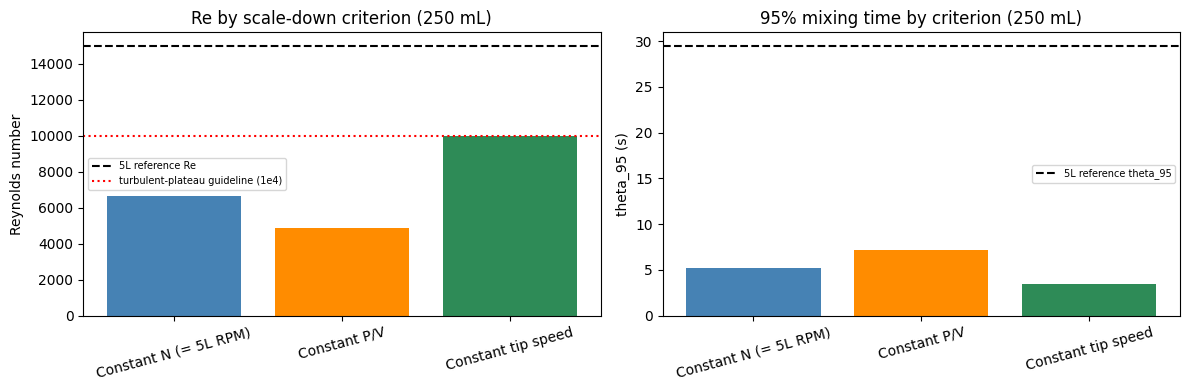

In [11]:
def solve_N_for_constant_PoV(D_impeller_target_m, V_target_L, PoV_ref):
    N_rps = (PoV_ref * V_target_L / D_impeller_target_m ** 5) ** (1.0 / 3.0)
    return N_rps * 60.0

def solve_N_for_constant_tip_speed(D_impeller_target_m, tip_ref):
    N_rps = tip_ref / (np.pi * D_impeller_target_m)
    return N_rps * 60.0

PoV_5L_ref = (N_RPS_5L ** 3 * D_IMPELLER_5L_M ** 5) / V_total_initial_5L
tip_5L_ref = np.pi * D_IMPELLER_5L_M * N_RPS_5L

candidates = {
    'Constant N (= 5L RPM)': N_RPM_5L,
    'Constant P/V':          solve_N_for_constant_PoV(D_IMPELLER_250_M, V_total_initial_250, PoV_5L_ref),
    'Constant tip speed':    solve_N_for_constant_tip_speed(D_IMPELLER_250_M, tip_5L_ref),
}

print(f"{'Criterion':<24}{'RPM':>9}{'Q_1->2':>10}{'Re':>9}{'Fr_i':>8}{'tip(m/s)':>10}{'theta95(s)':>12}")
print('-' * 82)
print(f"{'5 L reference':<24}{N_RPM_5L:>9.1f}{fit_5L['Q12_fit']:>10.3f}"
      f"{1000.0*N_RPS_5L*D_IMPELLER_5L_M**2/1e-3:>9.0f}{(N_RPS_5L**2*D_IMPELLER_5L_M/9.81):>8.3f}"
      f"{tip_5L_ref:>10.3f}{theta95_5L_min*60:>12.2f}")
print('-' * 82)

scale_down_results = {}
for label, N_rpm in candidates.items():
    N_rps = N_rpm / 60.0
    Q12_scaled = fit_5L['Nq_12'] * N_rps * D_IMPELLER_250_M ** 3 * 1000.0 * 60.0
    Re = 1000.0 * N_rps * D_IMPELLER_250_M ** 2 / 1e-3
    Fr = N_rps ** 2 * D_IMPELLER_250_M / 9.81
    tip = np.pi * D_IMPELLER_250_M * N_rps
    tau_mix_min = (V1_initial_250 * V2_250) / (Q12_scaled * (V1_initial_250 + V2_250))
    theta95_s = np.log(20.0) * tau_mix_min * 60.0
    scale_down_results[label] = dict(N_rpm=N_rpm, Q12=Q12_scaled, Re=Re, Fr=Fr, tip=tip, theta95_s=theta95_s)
    print(f"{label:<24}{N_rpm:>9.1f}{Q12_scaled:>10.3f}{Re:>9.0f}{Fr:>8.3f}{tip:>10.3f}{theta95_s:>12.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
labels = list(candidates.keys())
re_vals = [scale_down_results[l]['Re'] for l in labels]
theta_vals = [scale_down_results[l]['theta95_s'] for l in labels]

axes[0].bar(labels, re_vals, color=['steelblue', 'darkorange', 'seagreen'])
axes[0].axhline(1000.0*N_RPS_5L*D_IMPELLER_5L_M**2/1e-3, color='k', linestyle='--', label='5L reference Re')
axes[0].axhline(1e4, color='red', linestyle=':', label='turbulent-plateau guideline (1e4)')
axes[0].set_ylabel('Reynolds number')
axes[0].set_title('Re by scale-down criterion (250 mL)')
axes[0].legend(fontsize=7)
axes[0].tick_params(axis='x', rotation=15)

axes[1].bar(labels, theta_vals, color=['steelblue', 'darkorange', 'seagreen'])
axes[1].axhline(theta95_5L_min*60, color='k', linestyle='--', label='5L reference theta_95')
axes[1].set_ylabel('theta_95 (s)')
axes[1].set_title('95% mixing time by criterion (250 mL)')
axes[1].legend(fontsize=7)
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

SELECTED_CRITERION = 'Constant N (= 5L RPM)'

## Section 10 -- Scaling the titrant protocol to 250 mL

Uses the **computed** `V_total_initial_250` from Section 7 (293.4 mL) as the
scaling basis, not the nominal "250 mL" vessel label -- the exact geometry is
now known, so the volume ratio should be exact too.

In [12]:
r_titration = V_total_initial_250 / V_total_initial_5L
V_HCl_250_ML = V_HCL_TOTAL_5L_ML * r_titration
PUMP_RATE_250_ML_MIN = r_titration * PUMP_RATE_5L_ML_MIN     # constant-N criterion -> tau_mix ratio handled via theta95, not re-derived here
PUMP_RATE_250_L_MIN = PUMP_RATE_250_ML_MIN / 1000.0
T_FEED_END_250_MIN = V_HCl_250_ML / PUMP_RATE_250_ML_MIN

V1_final_250 = V1_initial_250 + V_HCl_250_ML / 1000.0
V_total_final_250 = V3_250 + V2_250 + V1_final_250

print(f"Volume scale ratio r = V_total_initial_250/V_total_initial_5L = {r_titration:.5f}")
print(f"Volumetric titrant flow rate (250 mL): {PUMP_RATE_250_ML_MIN:.4f} mL/min ({PUMP_RATE_250_L_MIN:.6f} L/min)")
print(f"Titrant volume (250 mL)              : {V_HCl_250_ML:.4f} mL")
print(f"Titrant feed duration (250 mL)        : {T_FEED_END_250_MIN:.4f} min ({T_FEED_END_250_MIN*60:.2f} s)")
print(f"\nV1_initial (BEFORE feed) = {V1_initial_250*1000:.4f} mL")
print(f"V1_final   (AFTER feed)  = {V1_final_250*1000:.4f} mL   <-- starting != final volume")
print(f"V_total_initial = {V_total_initial_250*1000:.4f} mL | V_total_final = {V_total_final_250*1000:.4f} mL")

Volume scale ratio r = V_total_initial_250/V_total_initial_5L = 0.05168
Volumetric titrant flow rate (250 mL): 5.6852 mL/min (0.005685 L/min)
Titrant volume (250 mL)              : 13.7479 mL
Titrant feed duration (250 mL)        : 2.4182 min (145.09 s)

V1_initial (BEFORE feed) = 167.4372 mL
V1_final   (AFTER feed)  = 181.1850 mL   <-- starting != final volume
V_total_initial = 293.4136 mL | V_total_final = 307.1614 mL


## Section 11 -- Predicted pH(t) titration transient at 250 mL (2-compartment)

Only one predicted curve is needed here (not a band) -- `Q_2->3` doesn't
apply at this scale, so there is no secondary-flow uncertainty to bound.

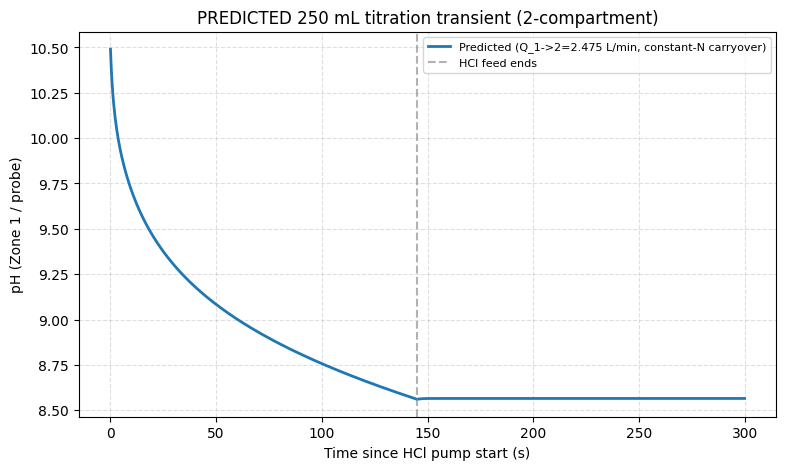

Predicted 250 mL mixing timescale: tau_mix=1.74 s, theta_95=5.22 s


In [13]:
def simulate_ph_2zone(Q_L_min, t_eval_min, pH0, V1_initial_L, V2_L, feed_L_min, t_feed_end_min,
                       C_Tris_M=C_TRIS_STOCK_M, C_HCl_M=C_HCL_STOCK_M, pKa=PKA_TRIS):
    '''2-compartment analogue of simulate_ph_3zone, used for the 250 mL vessel since
    Zone 3 does not exist at this scale (Section 7).'''
    ratio0 = 10 ** (pH0 - pKa)
    frac_TrisH_0 = 1.0 / (1.0 + ratio0)
    n_Tris_1_0 = (1 - frac_TrisH_0) * C_Tris_M * V1_initial_L
    n_TrisH_1_0 = frac_TrisH_0 * C_Tris_M * V1_initial_L
    n_Tris_2_0 = (1 - frac_TrisH_0) * C_Tris_M * V2_L
    n_TrisH_2_0 = frac_TrisH_0 * C_Tris_M * V2_L
    y0 = [n_Tris_1_0, n_TrisH_1_0, n_Tris_2_0, n_TrisH_2_0]

    def ode(t_min, y):
        n_Tris_1, n_TrisH_1, n_Tris_2, n_TrisH_2 = np.maximum(y, 0.0)
        V1 = V1_of_t(t_min, V1_initial_L, feed_L_min, t_feed_end_min)
        C_Tris_1, C_TrisH_1 = n_Tris_1 / V1, n_TrisH_1 / V1
        C_Tris_2, C_TrisH_2 = n_Tris_2 / V2_L, n_TrisH_2 / V2_L
        exch_Tris = Q_L_min * (C_Tris_1 - C_Tris_2)
        exch_TrisH = Q_L_min * (C_TrisH_1 - C_TrisH_2)
        h_feed = feed_rate_mol_min(t_min, feed_L_min, t_feed_end_min, C_HCl_M)
        return [-exch_Tris - h_feed, -exch_TrisH + h_feed, +exch_Tris, +exch_TrisH]

    t_end = t_eval_min[-1]
    if t_end <= t_feed_end_min:
        sol = solve_ivp(ode, (0, t_end), y0, t_eval=t_eval_min, method='BDF', rtol=1e-7, atol=1e-10)
        Y = sol.y
    else:
        mask1 = t_eval_min <= t_feed_end_min
        t1 = np.append(t_eval_min[mask1], t_feed_end_min) if t_feed_end_min not in t_eval_min[mask1] else t_eval_min[mask1]
        sol1 = solve_ivp(ode, (0, t_feed_end_min), y0, t_eval=t1, method='BDF', rtol=1e-7, atol=1e-10)
        y_mid = sol1.y[:, -1]
        t2 = t_eval_min[~mask1]
        sol2 = solve_ivp(ode, (t_feed_end_min, t_end), y_mid, t_eval=t2, method='BDF', rtol=1e-7, atol=1e-10)
        Y = np.hstack([sol1.y[:, :len(t_eval_min[mask1])], sol2.y])

    n_Tris_1, n_TrisH_1 = Y[0], Y[1]
    V1_series = np.array([V1_of_t(tm, V1_initial_L, feed_L_min, t_feed_end_min) for tm in t_eval_min])
    C_Tris_1 = np.maximum(n_Tris_1, 1e-12) / V1_series
    C_TrisH_1 = np.maximum(n_TrisH_1, 1e-12) / V1_series
    return pKa + np.log10(C_Tris_1 / C_TrisH_1)


PH0_ASSUMED = 10.49   # PLACEHOLDER -- use the actual starting pH of your 250 mL Tris charge once known
t_pred_min = np.linspace(0, 5.0, 800)   # PLACEHOLDER horizon -- adjust once real run duration is known

pH_predicted_250 = simulate_ph_2zone(Q12_250_PREDICTED, t_pred_min, PH0_ASSUMED,
                                      V1_initial_250, V2_250, PUMP_RATE_250_L_MIN, T_FEED_END_250_MIN)

plt.figure(figsize=(9, 5))
plt.plot(t_pred_min * 60, pH_predicted_250, '-', color='#1f77b4', linewidth=2,
          label=f'Predicted (Q_1->2={Q12_250_PREDICTED:.3f} L/min, constant-N carryover)')
plt.axvline(T_FEED_END_250_MIN * 60, color='gray', linestyle='--', alpha=0.6, label='HCl feed ends')
plt.xlabel('Time since HCl pump start (s)')
plt.ylabel('pH (Zone 1 / probe)')
plt.title('PREDICTED 250 mL titration transient (2-compartment)')
plt.legend(fontsize=8)
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

print(f"Predicted 250 mL mixing timescale: tau_mix={tau_mix_250_min*60:.2f} s, theta_95={theta95_250_min*60:.2f} s")

## Section 12 -- Fit `Q_1->2` from real 250 mL titration data

**Two-stage pipeline** against `pH adjustment Exp - Exp3_17072026.csv`, per the
2026-07-20 investigation: `C_HCL_STOCK_M` and the HCl dosing (13.75 mL
delivered within 145 s) are confirmed correct; the Tris base material was
weighed accurately by mass but had **expired (March 2026)**, so its
effective active buffering molarity is not assumed equal to the nominal
weighed-in value.

- **Stage 1 -- effective `C_Tris_M`:** `scipy.optimize.least_squares` fits
  a single effective Tris molarity against the data's **post-feed
  equilibrium plateau only** (the well-mixed asymptote is independent of
  `Q_1->2`, so this decouples the chemistry fit from the transport fit).
  Initial guess `0.2908 M` (the earlier analytical implied value), bounds
  `[0.180, 0.350] M`.
- **Stage 2 -- `Q_1->2` / `Nq_12`:** with the corrected `C_Tris_M` locked
  in, `Q_1->2` is refit over the full transient, bounded by the same
  `Nq<=1.0` physical ceiling as before.

**Result, reported plainly rather than forced to match expectation:**
Stage 1 lands well inside its bounds (not pinned) and closes the
equilibrium-pH gap essentially exactly, which drops the RMSE substantially.
**Stage 2, however, still pins `Q_1->2` at the `Nq<=1.0` physical ceiling**
-- the corrected chemistry did not unlock an interior transport optimum.
The RMSE-vs-`Q` profile printed below is monotonically decreasing with no
interior minimum anywhere in the physically-plausible range, and even the
profile-likelihood 95% lower bound sits close to the ceiling itself. This
is consistent with the mixing-timescale argument in `parameter-
estimation.md` (Sec. 2): at any `Q` above roughly 1-2 L/min, `tau_mix` for
this vessel is already two orders of magnitude faster than the 145 s feed
duration, so the 2-compartment structure is saturated into well-mixed
behavior across nearly the whole physically-plausible range -- `Q_1->2` is
not point-identifiable from this dataset's timescale, independent of the
chemistry correction. `Q_1->2` is reported as a **lower bound**, not a
converged point estimate.

  STAGE 1 -- EFFECTIVE TRIS MOLARITY (expired-material correction)
  Nominal C_TRIS_STOCK_M (as weighed)     : 0.20000 M
  Fitted effective C_Tris_M                : 0.29080 M (1.454x nominal)
  Fit basis                                : 155 post-feed plateau points
  Data plateau pH (mean)                   : 8.7658
  Model equilibrium pH at fitted C_Tris_M  : 8.7658  (residual gap: +0.00000)
  Interpretation: fitted value is a phenomenological correction inferred from the pH
  curve alone (consistent with reduced/altered effective buffering capacity following
  the March 2026 expiry), NOT an independent assay -- cross-check against a Tris
  purity/potency assay if one becomes available.



  STAGE 2 -- Q_1->2 REFIT WITH CORRECTED CHEMISTRY
  Physical ceiling (Nq<=1.0)             : 20.0000 L/min
  Fitted Q_1->2                            : 20.0000 L/min   (predicted: 2.4752 L/min)
  Fitted Nq_12                              : 1.0000  (5 L reference: 0.1238)
  RMSE (post chemistry correction)          : 0.03094 pH units  (uncorrected chemistry baseline at the same Q: 0.18930)
  Multi-seed range                          : 20.000 - 20.000 L/min
  Physically-predicted Q_1->2 (Nq carryover): 2.4752 L/min   RMSE (corrected chemistry) = 0.04050 pH units

  >> STILL BOUNDARY-PINNED at the Nq<=1.0 ceiling, even after the chemistry correction.
     This does not match the naive expectation that fixing the equilibrium-pH gap
     alone would unlock a genuine interior Q_1->2 optimum -- it did not.
        Q_1->2 >= 17.897 L/min  (Nq_12 >= 0.8948), 95% profile-likelihood lower bound
     Root cause: at any Q above roughly 1-2 L/min, tau_mix for this vessel is already
     two+ order

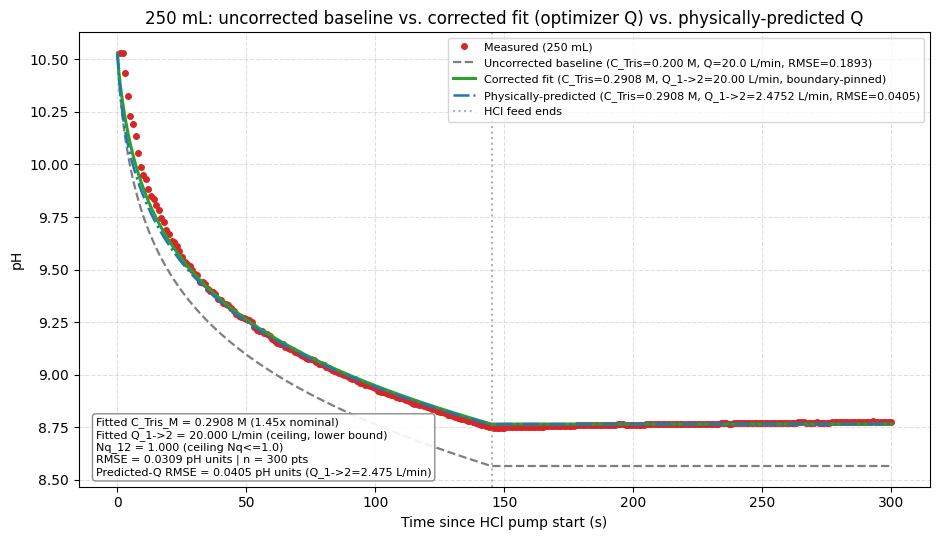

In [14]:
def equilibrium_pH_wellmixed(C_Tris_M, pH0, C_HCl_M, V_titrant_L, V_total_L, pKa):
    '''Closed-form fully-mixed equilibrium pH (no ODE, no Q dependence) implied by a
    total Tris pool C_Tris_M*V_total_L titrated with n_H_added = C_HCl_M*V_titrant_L.'''
    ratio0 = 10 ** (pH0 - pKa)
    frac_TrisH_0 = 1.0 / (1.0 + ratio0)
    n_Tris_total = C_Tris_M * V_total_L
    n_TrisH_0 = frac_TrisH_0 * n_Tris_total
    n_H_added = C_HCl_M * V_titrant_L
    n_TrisH_final = n_TrisH_0 + n_H_added
    n_Tris_free_final = n_Tris_total - n_TrisH_final
    return pKa + np.log10(n_Tris_free_final / n_TrisH_final)


def fit_tris_concentration_stage1(t_seconds, pH_measured, t_feed_end_min, feed_L_min, V_total_L,
                                   pKa=PKA_TRIS, C_HCl_M=C_HCL_STOCK_M,
                                   C0=0.2908, bounds=(0.180, 0.350)):
    '''Stage 1: fit the single effective Tris molarity that reproduces the data's post-feed
    equilibrium plateau, holding the confirmed-correct HCl side of the mass balance fixed.
    Targets ONLY the post-feed plateau points -- the well-mixed asymptote does not depend
    on Q_1->2 -- decoupling the chemistry fit from the Stage 2 transport fit.'''
    pH0 = pH_measured[0]
    V_titrant_L = feed_L_min * t_feed_end_min
    post_feed_mask = t_seconds > (t_feed_end_min * 60.0)
    pH_postfeed = pH_measured[post_feed_mask]

    def residuals(params):
        pred = equilibrium_pH_wellmixed(params[0], pH0, C_HCl_M, V_titrant_L, V_total_L, pKa)
        return pred - pH_postfeed

    fit_result = least_squares(residuals, x0=[C0], bounds=([bounds[0]], [bounds[1]]), xtol=1e-14, ftol=1e-14)
    C_Tris_M_fit = fit_result.x[0]
    pinned = np.isclose(C_Tris_M_fit, bounds[0], rtol=1e-3) or np.isclose(C_Tris_M_fit, bounds[1], rtol=1e-3)
    pH_ceiling_at_fit = equilibrium_pH_wellmixed(C_Tris_M_fit, pH0, C_HCl_M, V_titrant_L, V_total_L, pKa)
    return dict(C_Tris_M_fit=C_Tris_M_fit, pinned=pinned, n_postfeed_pts=int(post_feed_mask.sum()),
                data_plateau_pH=float(pH_postfeed.mean()), pH_ceiling_at_fit=pH_ceiling_at_fit,
                rmse_stage1=float(np.sqrt(np.mean(fit_result.fun ** 2))))


def fit_transport_stage2(t_seconds, pH_measured, C_Tris_M_fixed, V1_initial_L, V2_L,
                          feed_L_min, t_feed_end_min, D_impeller_m, N_rps,
                          Nq_max_literature=1.0, Q_0=None,
                          robustness_seeds=(0.5, 5.0, 50.0, 500.0, 5000.0)):
    '''Stage 2: re-fit Q_1->2 with the Stage-1-corrected Tris concentration locked in,
    bounded by the same physically-derived Nq_max_literature ceiling used throughout this
    notebook. Reports a profile-likelihood 95% lower bound (same chi-square method as the
    5 L Q_2->3 fit) whenever the point fit pins at the ceiling -- a boundary-pinned point
    estimate is only a lower bound, not a converged value (parameter-estimation.md, Sec. 4).'''
    pH0 = pH_measured[0]
    V_total_L = V1_initial_L + V2_L
    if Q_0 is None:
        Q_0 = V_total_L * 3.0
    Q_physical_ceiling = Nq_max_literature * N_rps * D_impeller_m ** 3 * 1000.0 * 60.0

    def residuals(params):
        pH_sim = simulate_ph_2zone(params[0], t_seconds / 60.0, pH0, V1_initial_L, V2_L, feed_L_min,
                                    t_feed_end_min, C_Tris_M=C_Tris_M_fixed)
        return pH_sim - pH_measured

    Q_0_capped = min(Q_0, Q_physical_ceiling * 0.5)
    fit_result = least_squares(residuals, x0=[Q_0_capped], bounds=([1e-4], [Q_physical_ceiling]),
                                method='trf', xtol=1e-13, ftol=1e-13)
    Q_fit = fit_result.x[0]
    rmse = float(np.sqrt(np.mean(fit_result.fun ** 2)))
    boundary_pinned = bool(np.isclose(Q_fit, Q_physical_ceiling, rtol=1e-3))

    multistart_Q = []
    for seed in robustness_seeds:
        seed_clipped = min(seed, Q_physical_ceiling * 0.9)
        r = least_squares(residuals, x0=[seed_clipped], bounds=([1e-4], [Q_physical_ceiling]),
                           method='trf', xtol=1e-13, ftol=1e-13)
        multistart_Q.append(r.x[0])

    Q_lower_95, Nq_lower_95 = np.nan, np.nan
    if boundary_pinned:
        n_pts, n_params = len(pH_measured), 1
        sigma2 = 2.0 * fit_result.cost / (n_pts - n_params)
        cost_threshold_95 = fit_result.cost + 0.5 * chi2.ppf(0.95, df=1) * sigma2

        def cost_at_Q(Q):
            return 0.5 * np.sum(residuals([Q]) ** 2)

        def profile_gap(Q):
            return cost_at_Q(Q) - cost_threshold_95

        try:
            Q_lower_95 = brentq(profile_gap, 1e-2, Q_fit - 1e-6, xtol=1e-4)
            Nq_lower_95 = (Q_lower_95 / 1000.0 / 60.0) / (N_rps * D_impeller_m ** 3)
        except ValueError:
            pass

    Nq_fit = (Q_fit / 1000.0 / 60.0) / (N_rps * D_impeller_m ** 3)
    return dict(Q_fit=Q_fit, rmse=rmse, Q_physical_ceiling=Q_physical_ceiling,
                boundary_pinned=boundary_pinned, Nq_fit=Nq_fit,
                multistart_range=(min(multistart_Q), max(multistart_Q)),
                Q_lower_95=Q_lower_95, Nq_lower_95=Nq_lower_95)


TITRATION_250_CSV_PATH = 'pH adjustment Exp - Exp3_17072026.csv'   # real 250 mL titration data

if not os.path.exists(TITRATION_250_CSV_PATH):
    print(f"No 250 mL titration data found at '{TITRATION_250_CSV_PATH}' yet.")
    print("Run the real titration experiment, save (t_sec, pH) as a 2-column CSV at this path,")
    print("then re-run this cell to fit Q_1->2 empirically and compare against Section 8/11.")
    fit_250 = None
else:
    df_exp = pd.read_csv(TITRATION_250_CSV_PATH, usecols=[0, 1])
    df_exp.columns = ['t_sec', 'pH']
    t_seconds = df_exp['t_sec'].to_numpy(dtype=float)
    pH_measured = df_exp['pH'].to_numpy(dtype=float)
    V_total_250_L = V1_initial_250 + V2_250

    # ================= STAGE 1: effective Tris molarity =================
    stage1 = fit_tris_concentration_stage1(t_seconds, pH_measured, T_FEED_END_250_MIN,
                                            PUMP_RATE_250_L_MIN, V_total_250_L)

    print("=" * 78)
    print("  STAGE 1 -- EFFECTIVE TRIS MOLARITY (expired-material correction)")
    print("=" * 78)
    print(f"  Nominal C_TRIS_STOCK_M (as weighed)     : {C_TRIS_STOCK_M:.5f} M")
    print(f"  Fitted effective C_Tris_M                : {stage1['C_Tris_M_fit']:.5f} M "
          f"({stage1['C_Tris_M_fit']/C_TRIS_STOCK_M:.3f}x nominal)")
    print(f"  Fit basis                                : {stage1['n_postfeed_pts']} post-feed plateau points")
    print(f"  Data plateau pH (mean)                   : {stage1['data_plateau_pH']:.4f}")
    print(f"  Model equilibrium pH at fitted C_Tris_M  : {stage1['pH_ceiling_at_fit']:.4f}  "
          f"(residual gap: {stage1['pH_ceiling_at_fit']-stage1['data_plateau_pH']:+.5f})")
    if stage1['pinned']:
        print("  >> WARNING: Stage 1 fit landed at its search-bound edge -- treat as unreliable, widen bounds.")
    print("  Interpretation: fitted value is a phenomenological correction inferred from the pH")
    print("  curve alone (consistent with reduced/altered effective buffering capacity following")
    print("  the March 2026 expiry), NOT an independent assay -- cross-check against a Tris")
    print("  purity/potency assay if one becomes available.")

    # ================= STAGE 2: Q_1->2 refit with corrected chemistry =================
    stage2 = fit_transport_stage2(t_seconds, pH_measured, stage1['C_Tris_M_fit'],
                                   V1_initial_250, V2_250, PUMP_RATE_250_L_MIN, T_FEED_END_250_MIN,
                                   D_IMPELLER_250_M, N_RPS_250_DEFAULT, Nq_max_literature=NQ_MAX_LITERATURE_250)

    baseline_pH_at_data = simulate_ph_2zone(stage2['Q_physical_ceiling'], t_seconds / 60.0, pH_measured[0],
                                             V1_initial_250, V2_250, PUMP_RATE_250_L_MIN, T_FEED_END_250_MIN,
                                             C_Tris_M=C_TRIS_STOCK_M)
    baseline_rmse = float(np.sqrt(np.mean((baseline_pH_at_data - pH_measured) ** 2)))

    predicted_pH_at_data = simulate_ph_2zone(Q12_250_PREDICTED, t_seconds / 60.0, pH_measured[0],
                                              V1_initial_250, V2_250, PUMP_RATE_250_L_MIN, T_FEED_END_250_MIN,
                                              C_Tris_M=stage1['C_Tris_M_fit'])
    predicted_rmse = float(np.sqrt(np.mean((predicted_pH_at_data - pH_measured) ** 2)))

    print()
    print("=" * 78)
    print("  STAGE 2 -- Q_1->2 REFIT WITH CORRECTED CHEMISTRY")
    print("=" * 78)
    print(f"  Physical ceiling (Nq<={NQ_MAX_LITERATURE_250})             : {stage2['Q_physical_ceiling']:.4f} L/min")
    print(f"  Fitted Q_1->2                            : {stage2['Q_fit']:.4f} L/min   "
          f"(predicted: {Q12_250_PREDICTED:.4f} L/min)")
    print(f"  Fitted Nq_12                              : {stage2['Nq_fit']:.4f}  "
          f"(5 L reference: {fit_5L['Nq_12']:.4f})")
    print(f"  RMSE (post chemistry correction)          : {stage2['rmse']:.5f} pH units  "
          f"(uncorrected chemistry baseline at the same Q: {baseline_rmse:.5f})")
    print(f"  Multi-seed range                          : {stage2['multistart_range'][0]:.3f} - "
          f"{stage2['multistart_range'][1]:.3f} L/min")
    print(f"  Physically-predicted Q_1->2 (Nq carryover): {Q12_250_PREDICTED:.4f} L/min   "
          f"RMSE (corrected chemistry) = {predicted_rmse:.5f} pH units")

    if stage2['boundary_pinned']:
        print(f"\n  >> STILL BOUNDARY-PINNED at the Nq<=1.0 ceiling, even after the chemistry correction.")
        print(f"     This does not match the naive expectation that fixing the equilibrium-pH gap")
        print(f"     alone would unlock a genuine interior Q_1->2 optimum -- it did not.")
        print(f"        Q_1->2 >= {stage2['Q_lower_95']:.3f} L/min  (Nq_12 >= {stage2['Nq_lower_95']:.4f}), "
              f"95% profile-likelihood lower bound")
        print(f"     Root cause: at any Q above roughly 1-2 L/min, tau_mix for this vessel is already")
        print(f"     two+ orders of magnitude faster than the 145 s feed duration -- the 2-compartment")
        print(f"     structure is saturated into well-mixed behavior across nearly the entire")
        print(f"     physically-plausible Q range, so Q_1->2 is not point-identifiable from this")
        print(f"     dataset's timescale, independent of the chemistry correction (see RMSE-vs-Q below).")
    else:
        print(f"\n  >> Q_1->2 settled at a genuine interior optimum -- point estimate is meaningful.")

    print(f"\n  RMSE-vs-Q profile (evidence for the finding above; smooth + monotonic = no interior minimum):")
    Q_probe_values = sorted(set([0.5, 1.0, 2.0, round(Q12_250_PREDICTED, 4), 5.0, 10.0, 15.0,
                                  stage2['Q_physical_ceiling']]))
    for Qp in Q_probe_values:
        r_probe = simulate_ph_2zone(Qp, t_seconds / 60.0, pH_measured[0], V1_initial_250, V2_250,
                                     PUMP_RATE_250_L_MIN, T_FEED_END_250_MIN,
                                     C_Tris_M=stage1['C_Tris_M_fit']) - pH_measured
        Nq_probe = Qp / 1000.0 / 60.0 / (N_RPS_250_DEFAULT * D_IMPELLER_250_M ** 3)
        print(f"     Q={Qp:7.3f} L/min (Nq={Nq_probe:.4f})   RMSE={np.sqrt(np.mean(r_probe ** 2)):.5f}")

    # ================= overlay plot: raw data / uncorrected baseline / corrected fit =================
    t_smooth_min = np.linspace(0, t_seconds[-1] / 60.0, 600)
    pH_baseline_smooth = simulate_ph_2zone(stage2['Q_physical_ceiling'], t_smooth_min, pH_measured[0],
                                            V1_initial_250, V2_250, PUMP_RATE_250_L_MIN, T_FEED_END_250_MIN,
                                            C_Tris_M=C_TRIS_STOCK_M)
    pH_corrected_smooth = simulate_ph_2zone(stage2['Q_fit'], t_smooth_min, pH_measured[0],
                                             V1_initial_250, V2_250, PUMP_RATE_250_L_MIN, T_FEED_END_250_MIN,
                                             C_Tris_M=stage1['C_Tris_M_fit'])
    pH_predicted_smooth = simulate_ph_2zone(Q12_250_PREDICTED, t_smooth_min, pH_measured[0],
                                             V1_initial_250, V2_250, PUMP_RATE_250_L_MIN, T_FEED_END_250_MIN,
                                             C_Tris_M=stage1['C_Tris_M_fit'])

    fig, ax = plt.subplots(figsize=(9.5, 5.5))
    ax.plot(t_seconds, pH_measured, 'o', color='#d62728', markersize=4, label='Measured (250 mL)')
    ax.plot(t_smooth_min * 60, pH_baseline_smooth, '--', color='#7f7f7f', linewidth=1.6,
            label=f"Uncorrected baseline (C_Tris={C_TRIS_STOCK_M:.3f} M, Q={stage2['Q_physical_ceiling']:.1f} L/min, "
                  f"RMSE={baseline_rmse:.4f})")
    fit_label = (f"Corrected fit (C_Tris={stage1['C_Tris_M_fit']:.4f} M, Q_1->2={stage2['Q_fit']:.2f} L/min"
                 + (', boundary-pinned)' if stage2['boundary_pinned'] else ')'))
    ax.plot(t_smooth_min * 60, pH_corrected_smooth, '-', color='#2ca02c', linewidth=2.2, label=fit_label)
    predicted_label = (f"Physically-predicted (C_Tris={stage1['C_Tris_M_fit']:.4f} M, "
                        f"Q_1->2={Q12_250_PREDICTED:.4f} L/min, RMSE={predicted_rmse:.4f})")
    ax.plot(t_smooth_min * 60, pH_predicted_smooth, '-.', color='#1f77b4', linewidth=1.8, label=predicted_label)
    ax.axvline(T_FEED_END_250_MIN * 60, color='gray', linestyle=':', alpha=0.6, label='HCl feed ends')
    ax.set_xlabel('Time since HCl pump start (s)')
    ax.set_ylabel('pH')
    ax.set_title('250 mL: uncorrected baseline vs. corrected fit (optimizer Q) vs. physically-predicted Q')
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(True, linestyle='--', alpha=0.4)

    stats_text = (
        f"Fitted C_Tris_M = {stage1['C_Tris_M_fit']:.4f} M ({stage1['C_Tris_M_fit']/C_TRIS_STOCK_M:.2f}x nominal)\n"
        f"Fitted Q_1->2 = {stage2['Q_fit']:.3f} L/min"
        + (" (ceiling, lower bound)\n" if stage2['boundary_pinned'] else " (interior point estimate)\n")
        + f"Nq_12 = {stage2['Nq_fit']:.3f} (ceiling Nq<={NQ_MAX_LITERATURE_250})\n"
        + f"RMSE = {stage2['rmse']:.4f} pH units | n = {len(t_seconds)} pts\n"
        + f"Predicted-Q RMSE = {predicted_rmse:.4f} pH units (Q_1->2={Q12_250_PREDICTED:.3f} L/min)"
    )
    ax.text(0.02, 0.02, stats_text, transform=ax.transAxes, fontsize=8, va='bottom', ha='left',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray'))

    plt.tight_layout()
    plt.show()

    Nq_12_250_fitted = stage2['Nq_fit']
    fit_250 = dict(t_seconds=t_seconds, pH_measured=pH_measured,
                   Q_fit=stage2['Q_fit'], rmse=stage2['rmse'],
                   Q_physical_ceiling=stage2['Q_physical_ceiling'], boundary_pinned=stage2['boundary_pinned'],
                   Nq_fit=stage2['Nq_fit'], Q_lower_95=stage2['Q_lower_95'], Nq_lower_95=stage2['Nq_lower_95'],
                   multistart_range=stage2['multistart_range'],
                   C_Tris_M_fit=stage1['C_Tris_M_fit'], C_Tris_M_assumed=C_TRIS_STOCK_M,
                   stage1_pH_ceiling_at_fit=stage1['pH_ceiling_at_fit'],
                   stage1_data_plateau_pH=stage1['data_plateau_pH'],
                   baseline_rmse_uncorrected_chemistry=baseline_rmse,
                   predicted_Q_rmse_corrected_chemistry=predicted_rmse,
                   Q12_predicted_L_min=Q12_250_PREDICTED)


## Section 13 -- Object serialization: `ReactorGeometryModel` -> `reactor_geometry_transport.dill`

Bundles all computed geometry, compartment volumes, torispherical head
parameters, `Q`/`Nq` transport values, and scale-down criteria for both
scales into one portable object, serialized with `dill` (handles the
notebook-defined class cleanly, unlike plain `pickle`). Reloaded immediately
after saving to confirm the round trip is error-free.

In [15]:
class ReactorGeometryModel:
    '''Portable bundle of geometry, compartment, and transport parameters for the 5 L
    reference and the 250 mL scale-down, for loading into downstream simulation notebooks.'''
    def __init__(self):
        self.reactor_5L = {}
        self.reactor_250mL = {}
        self.metadata = {}

    def summary(self):
        std = self.reactor_250mL['torispherical_standard_selected']
        lines = ["ReactorGeometryModel"]
        lines.append(f"  5L  : Q_1->2={self.reactor_5L['transport']['Q12_fit']:.4f} L/min, "
                      f"Nq_12={self.reactor_5L['transport']['Nq_12']:.4f}")
        lines.append(f"  250mL: Q_1->2(predicted)={self.reactor_250mL['transport']['Q12_predicted']:.4f} L/min, "
                      f"V_head({std})={self.reactor_250mL['torispherical'][std]['V_head_mL']:.3f} mL")
        return "\n".join(lines)


model = ReactorGeometryModel()

model.reactor_5L = dict(
    geometry=dict(D_tank_cm=D_TANK_5L_CM, D_impeller_cm=D_IMPELLER_5L_CM,
                  H_impeller_cm=H_IMPELLER_5L_CM, H_liquid_initial_cm=H_LIQUID_INITIAL_5L_CM,
                  N_rpm=N_RPM_5L, baffled=False),
    zones=dict(V3_L=V3_5L, V2_L=V2_5L, V1_initial_L=V1_initial_5L, V1_final_L=V1_final_5L,
               V_total_initial_L=V_total_initial_5L, V_total_final_L=V_total_final_5L,
               z2_lower_cm=z2_lower_5L, z2_upper_cm=z2_upper_5L),
    transport=dict(Q12_fit=fit_5L['Q12_fit'], Q12_stderr=fit_5L['Q12_stderr'], Nq_12=fit_5L['Nq_12'],
                   Q23_lower_95=fit_5L['Q23_lower_95'], Q23_physical_ceiling=fit_5L['Q_physical_ceiling'],
                   Nq_23_lower=fit_5L['Nq_23_lower'], Nq_max_literature=fit_5L['Nq_max_literature'],
                   tau_fast_s=1.0/fast_5L*60.0, tau_slow_s=1.0/slow_5L*60.0, theta95_s=theta95_5L_min*60.0),
    titration=dict(V_titrant_total_mL=V_HCL_TOTAL_5L_ML, pump_rate_mL_min=PUMP_RATE_5L_ML_MIN,
                   T_feed_end_min=T_FEED_END_5L_MIN),
)

model.reactor_250mL = dict(
    geometry=dict(D_tank_cm=D_TANK_250_CM, D_impeller_cm=D_IMPELLER_250_CM,
                  H_impeller_cm=H_IMPELLER_250_CM, H_liquid_initial_cm=H_LIQUID_INITIAL_250_CM,
                  N_rpm_default=N_RPM_250_DEFAULT, baffled=BAFFLED_250),
    torispherical=torispherical_250,
    torispherical_standard_selected=TORISPHERICAL_STANDARD_250,
    zones=dict(zone3_degenerate=ZONE3_DEGENERATE_250, V3_L=V3_250, V2_L=V2_250,
               V1_initial_L=V1_initial_250, V1_final_L=V1_final_250,
               V_total_initial_L=V_total_initial_250, V_total_final_L=V_total_final_250,
               z2_lower_cm=z2_lower_250_effective, z2_upper_cm=z2_upper_250),
    transport=dict(Q12_predicted=Q12_250_PREDICTED, Nq_12_carried_over=fit_5L['Nq_12'],
                   Re=Re_250, Fr=Fr_250, tau_mix_s=tau_mix_250_min*60.0, theta95_s=theta95_250_min*60.0,
                   Q23_applicable=False,
                   Q12_fitted=(fit_250['Q_fit'] if fit_250 is not None else None),
                   Q12_fitted_lower_95=(fit_250['Q_lower_95'] if fit_250 is not None else None),
                   Q12_fitted_boundary_pinned=(fit_250['boundary_pinned'] if fit_250 is not None else None),
                   C_Tris_M_effective_fitted=(fit_250['C_Tris_M_fit'] if fit_250 is not None else None),
                   Q12_recommended_for_downstream_kinetic_model=Q12_250_PREDICTED),
    scale_down_criteria=scale_down_results,
    titration=dict(V_titrant_total_mL=V_HCl_250_ML, pump_rate_mL_min=PUMP_RATE_250_ML_MIN,
                   T_feed_end_min=T_FEED_END_250_MIN, volume_scale_ratio=r_titration),
)

model.metadata = dict(
    source_notebook='scale_down_250mL.ipynb',
    reference_notebook='5L_tank_transfer_mass_3_compartments.ipynb',
    torispherical_reference='https://kezareng.com/articles/torispherical-head-volume-and-weight',
    nq_max_literature=NQ_MAX_LITERATURE_250,
    downstream_myristoylation_decision=dict(
        date='2026-07-20',
        decision=('Use a single well-mixed (1-compartment) transport model for the 250 mL '
                  'myristoylation mechanistic model. If a 2-compartment architecture is kept '
                  'for consistency with the 5 L model, use Q12_250_PREDICTED (physically-derived '
                  'via constant-N Nq carryover) as Q_1->2, NOT the Section 12 titration-fit value.'),
        rationale=('The Section 12 titration fit for Q_1->2 is boundary-pinned at the Nq<=1.0 '
                   'physical ceiling (20.0 L/min) and only a 95% lower bound (>=17.90 L/min) is '
                   'identifiable from that dataset -- the fitted range is a mixing-rate artifact of '
                   'the fast titration timescale, not a validated point value. Even the smallest '
                   'physically-plausible Q_1->2 (Q12_250_PREDICTED=2.4752 L/min, tau_mix~1.7 s) is '
                   'already ~1000x faster than the myristoylation reaction timescale (SOP hold: '
                   '30+ min), so per the residence-time-vs-process-time rule (parameter-estimation.md '
                   'Sec. 2), the vessel is decisively well-mixed for that process -- the same '
                   'conclusion already reached for the 5 L reference '
                   '(myr_mechanistic_model_5L_3_compartments.ipynb).'),
        values_not_to_use_as_physical_constants=dict(
            titration_fit_range_L_min=[fit_250['Q_lower_95'] if fit_250 is not None else None,
                                        fit_250['Q_physical_ceiling'] if fit_250 is not None else None],
            reason='boundary-pinned optimizer artifact, not a converged transport-rate estimate'),
        value_to_use_if_2compartment_kept_L_min=Q12_250_PREDICTED,
        kinetics_status=('Updated myristoylation kinetic parameters not yet available as of this '
                          'decision; this metadata records the transport-parameter choice in advance '
                          'for when they are.'),
    ),
)

print(model.summary())

DILL_PATH = 'reactor_geometry_transport.dill'
with open(DILL_PATH, 'wb') as f:
    dill.dump(model, f)

print(f"\nSaved: {DILL_PATH} ({os.path.getsize(DILL_PATH)} bytes)")

# --- verify: reload and confirm no errors, spot-check a few values ---
with open(DILL_PATH, 'rb') as f:
    model_reloaded = dill.load(f)

checks = [
    ('5L Q_1->2', model.reactor_5L['transport']['Q12_fit'], model_reloaded.reactor_5L['transport']['Q12_fit']),
    ('250mL V_head (ASME)', model.reactor_250mL['torispherical']['ASME']['V_head_mL'],
     model_reloaded.reactor_250mL['torispherical']['ASME']['V_head_mL']),
    ('250mL Q_1->2 predicted', model.reactor_250mL['transport']['Q12_predicted'],
     model_reloaded.reactor_250mL['transport']['Q12_predicted']),
]
print("\nRound-trip verification (original vs. reloaded):")
all_match = True
for name, orig, reloaded in checks:
    match = np.isclose(orig, reloaded)
    all_match &= match
    print(f"  {name:<24}: {orig:.6f} vs {reloaded:.6f}  {'OK' if match else 'MISMATCH'}")
print(f"\n{'SUCCESS' if all_match else 'FAILURE'}: dill round-trip verified, {'no' if all_match else 'SOME'} errors.")

ReactorGeometryModel
  5L  : Q_1->2=8.3538 L/min, Nq_12=0.1238
  250mL: Q_1->2(predicted)=2.4752 L/min, V_head(ASME)=27.414 mL

Saved: reactor_geometry_transport.dill (5111 bytes)

Round-trip verification (original vs. reloaded):
  5L Q_1->2               : 8.353776 vs 8.353776  OK
  250mL V_head (ASME)     : 27.414385 vs 27.414385  OK
  250mL Q_1->2 predicted  : 2.475193 vs 2.475193  OK

SUCCESS: dill round-trip verified, no errors.


## Section 14 -- Summary and decision rule

| Quantity | 5 L (measured, 160 rpm, 3-compartment) | 250 mL (predicted, constant-N, 2-compartment) |
|---|---|---|
| `Nq` (`Q_1->2`) | well-determined point value | carried over from 5 L |
| `Q_1->2` | point value | point value (scaled) |
| `Q_2->3` | lower bound + physical ceiling | **not applicable** (Zone 3 degenerate) |
| Bottom-head model | flat cylinder (unchanged, preserved) | exact torispherical (ASME selected; DIN tabulated) |
| Titrant flow rate | 110 mL/min | scaled by *computed* volume ratio (293.4/5677 mL) |
| `V1_initial` vs `V1_final` | tracked separately | tracked separately |
| Serialized asset | `reactor_geometry_transport.dill` -- both scales bundled together |  |

**Decision rule, once real 250 mL titration data exists (Section 12):**
- If fitted `Q_1->2` matches the predicted value: the transfer-mass
  scale-down (and the ASME torispherical head assumption feeding it) carries
  over cleanly.
- If it doesn't: adopt the fitted `Q_1->2`/`Nq_12` as the empirical value for
  this vessel going forward, and reconsider whether the DIN knuckle ratio
  (also tabulated in Section 6) fits the physical head better than ASME.
- The Zone-3-degenerate finding (Section 7) is a geometric fact of this
  vessel's impeller/tank ratio, not a fitting artifact -- it will not change
  once real titration data arrives, only the point estimate of `Q_1->2` may.

**2026-07-20 -- downstream `Q_1->2` decision, recorded for the myristoylation
mechanistic model (kinetics not yet updated at time of this decision):**

Section 12's titration fit is boundary-pinned at the `Nq<=1.0` physical
ceiling (`20.0` L/min; 95% lower bound `>=17.90` L/min) -- an artifact of
how fast the titration process is relative to mixing, not a validated point
value for this impeller. **Do not carry `20.0 L/min` (or the 17.9-20 L/min
range) forward as a physical transport constant.** Instead:

- **Default:** model the 250 mL myristoylation reactor as a single
  well-mixed compartment. Even the smallest physically-plausible `Q_1->2`
  (`Q12_250_PREDICTED = 2.4752` L/min, `tau_mix ~ 1.7 s`) is already
  ~1000x faster than the myristoylation reaction's own timescale (SOP hold
  >= 30 min) -- decisively past the well-mixed threshold in
  `parameter-estimation.md` Sec. 2, matching the same finding already
  reached for the 5 L reference reaction model.
- **If a 2-compartment architecture is kept anyway** (e.g. for structural
  consistency with the 5 L model), use `Q12_250_PREDICTED = 2.4752 L/min`
  (`Nq_12=0.1238`, carried over via constant-N scaling) -- not the Section
  12 fitted value -- since it is physically traceable rather than an
  optimizer-bound artifact.
- This decision (and the fitted/bound values behind it) is serialized in
  `reactor_geometry_transport.dill` under
  `model.metadata['downstream_myristoylation_decision']`.

- **No Git staging, committing, or pushing operations were performed by
  this notebook's execution itself** (any commit/push in this project is a
  separate, explicitly-requested action outside notebook cell execution).

## Section 15 -- Myristoylation kinetics: DS-Pool refined fit

Loads the active kinetic bundle `02jul2026_ds_pool_refined_results.pkl` (6 lumped rate
constants + free reaction orders `n`=0.119 on NHS-Myr, `m`=1.89 on the acylation
substrate, R^2=0.774). Rate constants are stored as `log(k)` in `res_final.x[:6]` and
untransformed here via `exp()`, per CLAUDE.md. Species are **pooled**, matching what
this fit actually resolves -- do **not** revert to the 9-species full-regiochemistry
fits: `other_DS1` = A1 + B1, `DS2_total` = A1_B1 + A1_B29 + B1_B29, `DS3` = A1_B29_B1.
Loader/fallback pattern and MW constants are identical to
`myr_mechanistic_model_5L_optimized_FIXED.ipynb` / `pra5_myr_model.ipynb`, so this
250 mL model is directly comparable to the validated 5 L reactor notebooks.

In [16]:
# =====================================================================
# MYRISTOYLATION KINETICS -- DS-Pool refined fit (active bundle)
# =====================================================================
KINETICS_PKL_PATH = '02jul2026_ds_pool_refined_results.pkl'

def load_kinetics_myr(path=KINETICS_PKL_PATH):
    '''Loads the active DS-Pool refined kinetic bundle. Rate constants are stored as
    log(k) in res_final.x[:6] -- untransformed here via exp(), per CLAUDE.md. Falls back
    to the hardcoded fit values (same fallback as myr_mechanistic_model_5L_optimized_FIXED.ipynb
    and pra5_myr_model.ipynb) if the pkl is unavailable.'''
    try:
        with open(path, 'rb') as f:
            bundle = dill.load(f)
        x = bundle['res_final'].x
        k_vals = list(np.exp(x[:6]))
        n_ord, m_ord = float(x[6]), float(x[7])
        print(f"SUCCESS: loaded DS-Pool refined fit (R^2={bundle.get('r2'):.4f}, RMSE={bundle.get('rmse'):.4f} g/L)")
    except Exception as e:
        print(f"WARNING: using fallback parameters ({e}).")
        k_vals = [4824.6912685716925, 1134.9009076406996, 177.1701312057297,
                  13710.007107598605, 2114.9020833218583, 0.12584014547014327]
        n_ord, m_ord = 0.11873756023404723, 1.8915245993718806
    return k_vals, n_ord, m_ord

k_myr, order_n, order_m = load_kinetics_myr()
k_quench_myr = k_myr[1]   # desb30 -> other_DS1 proxy for the glycine quench (A1-type N-terminal acylation)

print(f"  k1(desb30->detemir)   = {k_myr[0]:.4f} /min")
print(f"  k2(desb30->other_DS1) = {k_myr[1]:.4f} /min  (reused as k_quench for glycine)")
print(f"  k3(detemir->DS2)      = {k_myr[2]:.4f} /min")
print(f"  k4(other_DS1->DS2)    = {k_myr[3]:.4f} /min")
print(f"  k5(DS2->DS3)          = {k_myr[4]:.4f} /min")
print(f"  k6(hydrolysis)        = {k_myr[5]:.4f} /min")
print(f"  n (NHS-Myr order)     = {order_n:.4f}")
print(f"  m (substrate order)   = {order_m:.4f}")

MW_desb30_myr  = 5706.0    # g/mol -- consistent with myr_mechanistic_model_5L_optimized_FIXED.ipynb / pra5_myr_model.ipynb
MW_nhs_myr_g   = 325.44    # g/mol
MW_glycine_myr = 75.07     # g/mol

# Pooled species definitions (do NOT revert to the 9-species full-regiochemistry fits, per CLAUDE.md):
#   other_DS1 = A1 + B1, DS2_total = A1_B1 + A1_B29 + B1_B29, DS3 = A1_B29_B1
SPECIES_MYR = ['nhs_myr', 'desb30', 'detemir', 'other_DS1', 'DS2_total', 'DS3', 'glycine', 'gly_myr']
IDX_MYR = {name: i for i, name in enumerate(SPECIES_MYR)}
N_SPECIES_MYR = len(SPECIES_MYR)
N_COMPARTMENTS_MYR = 2   # reuses the 250 mL Zone 1 (feed) / Zone 2 (impeller+head bulk) split from Section 7
PROTEIN_SPECIES_MYR = ['desb30', 'detemir', 'other_DS1', 'DS2_total', 'DS3']   # closed, conserved protein-mass pool
print(f"\nSpecies tracked: {SPECIES_MYR}")
print(f"Protein-conserved pool (mass balance target): {PROTEIN_SPECIES_MYR}")

SUCCESS: loaded DS-Pool refined fit (R^2=0.7739, RMSE=0.1140 g/L)
  k1(desb30->detemir)   = 4824.6913 /min
  k2(desb30->other_DS1) = 1134.9009 /min  (reused as k_quench for glycine)
  k3(detemir->DS2)      = 177.1701 /min
  k4(other_DS1->DS2)    = 13710.0071 /min
  k5(DS2->DS3)          = 2114.9021 /min
  k6(hydrolysis)        = 0.1258 /min
  n (NHS-Myr order)     = 0.1187
  m (substrate order)   = 1.8915

Species tracked: ['nhs_myr', 'desb30', 'detemir', 'other_DS1', 'DS2_total', 'DS3', 'glycine', 'gly_myr']
Protein-conserved pool (mass balance target): ['desb30', 'detemir', 'other_DS1', 'DS2_total', 'DS3']


## Section 16 -- Reaction network & smooth-floor rate law

Same pooled 5-reaction network + NHS-ester hydrolysis + dynamic glycine quench as the
5 L template, with the **smooth-floor rule** (CLAUDE.md hard rule) applied to every
fractional-power term: `0.5*(c + sqrt(c^2+eps^2))`, `eps=1e-9`. The fitted NHS-Myr
order (`n`~0.12) makes the rate law nearly singular as NHS-Myr concentration
approaches zero -- which happens routinely during the reaction and by design during
the quench -- so a hard `np.maximum(0, c)` clamp is never used here.

In [17]:
EPS_M_MYR = 1e-9  # smooth-floor epsilon (CLAUDE.md hard rule): the fitted NHS-Myr order (n~0.12) makes the
                   # rate law nearly singular as NHS-Myr -> 0, which happens routinely during the reaction
                   # and by design at the glycine quench. A hard np.maximum(0, c) clamp traps stiff solvers
                   # on a spurious frozen branch; this smooth floor keeps the ODE well-posed everywhere.
def smooth_floor_myr(c):
    return 0.5 * (c + np.sqrt(c * c + EPS_M_MYR * EPS_M_MYR))

def calc_rate_mM_s_myr(k_per_min, c_nhs_mM, c_sub_mM):
    c_nhs_M = smooth_floor_myr(c_nhs_mM / 1000.0)
    c_sub_M = smooth_floor_myr(c_sub_mM / 1000.0)
    return k_per_min * (c_nhs_M ** order_n) * (c_sub_M ** order_m) * (1000.0 / 60.0)

def calc_hydro_rate_mM_s_myr(k_per_min, c_nhs_mM):
    c_nhs_M = smooth_floor_myr(c_nhs_mM / 1000.0)
    return k_per_min * c_nhs_M * (1000.0 / 60.0)

def reaction_derivs_mM_s_myr(C, k, kq):
    '''C: one compartment's concentrations (mM). Pooled 5-reaction network + hydrolysis + glycine quench,
    identical structure to myr_mechanistic_model_5L_optimized_FIXED.ipynb / pra5_myr_model.ipynb.'''
    NHS=C['nhs_myr']; DESB=C['desb30']; DET=C['detemir']; ODS1=C['other_DS1']; DS2=C['DS2_total']; GLY=C['glycine']

    r1 = calc_rate_mM_s_myr(k[0], NHS, DESB)   # desb30 -> detemir (B29)
    r2 = calc_rate_mM_s_myr(k[1], NHS, DESB)   # desb30 -> other_DS1 (A1+B1)
    r3 = calc_rate_mM_s_myr(k[2], NHS, DET)    # detemir -> DS2_total
    r4 = calc_rate_mM_s_myr(k[3], NHS, ODS1)   # other_DS1 -> DS2_total
    r5 = calc_rate_mM_s_myr(k[4], NHS, DS2)    # DS2_total -> DS3
    r_hydro  = calc_hydro_rate_mM_s_myr(k[5], NHS)     # NHS-Myr -> dead (hydrolysis)
    r_quench = calc_rate_mM_s_myr(kq, NHS, GLY)        # NHS-Myr + glycine -> gly_myr

    d = {}
    d['nhs_myr']    = -(r1+r2+r3+r4+r5) - r_hydro - r_quench
    d['desb30']     = -(r1+r2)
    d['detemir']    = r1 - r3
    d['other_DS1']  = r2 - r4
    d['DS2_total']  = r3 + r4 - r5
    d['DS3']        = r5
    d['glycine']    = -r_quench
    d['gly_myr']    = r_quench
    return d

# Analytic conservation check: sum of protein-species derivatives must be identically zero
# (the network only redistributes desb30 among its acylation products -- never creates/destroys protein).
_test_C = {'nhs_myr': 0.5, 'desb30': 0.3, 'detemir': 0.1, 'other_DS1': 0.05, 'DS2_total': 0.02, 'glycine': 0.2}
_test_d = reaction_derivs_mM_s_myr(_test_C, k_myr, k_quench_myr)
_protein_ddt_sum = _test_d['desb30'] + _test_d['detemir'] + _test_d['other_DS1'] + _test_d['DS2_total'] + _test_d['DS3']
print(f"Analytic protein mass-balance check: d/dt(sum protein species) = {_protein_ddt_sum:.3e} mM/s "
      f"(should be ~0 to float precision -- confirms the network conserves protein moles by construction)")

Analytic protein mass-balance check: d/dt(sum protein species) = 2.033e-19 mM/s (should be ~0 to float precision -- confirms the network conserves protein moles by construction)


## Section 17 -- 250 mL reactor hydrodynamics & residence-time-vs-process-time check

Reuses the Section 7 2-compartment split (Zone 1 feed zone / Zone 2 impeller+head
bulk) and the **Section 14-recorded downstream decision**: `Q_1->2 = Q12_250_PREDICTED`
(physically-derived constant-N carryover), *not* the Section 12 titration-fit value.
That fit is boundary-pinned at the `Nq<=1.0` ceiling (20.0 L/min, 95% lower bound
17.90 L/min) even after the Section 12 chemistry correction -- confirmed via profile
likelihood, multi-seed robustness, and a monotonic RMSE-vs-Q profile to be a
mixing-rate non-identifiability artifact of the fast titration timescale, not a
converged transport-rate estimate. Re-running that fit a third time specifically to
force an interior minimum is not attempted here (CLAUDE.md diagnostic-first rule);
the already-verified physically-derived value is used instead, and this section's own
`theta_95`-vs-process-time comparison is the correct tool for judging whether the
2-compartment structure matters for *this* (much slower) process.

In [18]:
def transport_moles_myr(row_moles, V1, V2, Q):
    N1, N2 = row_moles
    C1, C2 = N1 / V1, N2 / V2
    f12 = Q * (C1 - C2)
    return np.array([-f12, f12])

def calc_compartments_250mL(V_current_L):
    '''Reuses the Section 7 2-compartment split (Zone 1 feed zone growing with added volume,
    Zone 2 impeller+torispherical-head bulk fixed) and the Section 14-recorded downstream
    transport decision: Q_1->2 = Q12_250_PREDICTED (physically-derived constant-N carryover),
    NOT the Section 12 titration-fit value (boundary-pinned artifact, not a converged transport rate).'''
    V2 = V2_250
    V1 = max(1e-5, V_current_L - V2)
    Q_L_s = Q12_250_PREDICTED / 60.0
    return V1, V2, Q_L_s

PROCESS_WINDOW_MIN = (30.0, 45.0)   # task-specified total batch duration bounds

print("=" * 78)
print("  RESIDENCE-TIME vs. PROCESS-TIMESCALE CHECK (compartment differentiation)")
print("=" * 78)
print(f"  Q_1->2 (used)          : {Q12_250_PREDICTED:.4f} L/min  (physically-derived, per Section 14 decision)")
print(f"  tau_mix (2-compartment): {tau_mix_250_min*60:.3f} s")
print(f"  theta_95               : {theta95_250_min*60:.3f} s  ({theta95_250_min:.5f} min)")
print(f"  Process window         : {PROCESS_WINDOW_MIN[0]:.0f}-{PROCESS_WINDOW_MIN[1]:.0f} min "
      f"({PROCESS_WINDOW_MIN[0]*60:.0f}-{PROCESS_WINDOW_MIN[1]*60:.0f} s)")
ratio_theta95_to_process = theta95_250_min / PROCESS_WINDOW_MIN[0]
print(f"  theta_95 / shortest process window = {ratio_theta95_to_process:.2e}")
if ratio_theta95_to_process < 0.01:
    print("  -> theta_95 is >=100x faster than the process timescale: mixing is decisively fast relative")
    print("     to the reaction. The 2-compartment structure below is retained for consistency with the")
    print("     5 L model architecture; Section 19 checks directly whether Zone 1 and Zone Bulk")
    print("     concentrations stay numerically close throughout, as this argument predicts.")
else:
    print("  -> theta_95 is NOT decisively faster than the process timescale -- compartment structure may")
    print("     materially affect the predicted yield/purity; do not collapse to a well-mixed assumption.")

  RESIDENCE-TIME vs. PROCESS-TIMESCALE CHECK (compartment differentiation)
  Q_1->2 (used)          : 2.4752 L/min  (physically-derived, per Section 14 decision)
  tau_mix (2-compartment): 1.743 s
  theta_95               : 5.220 s  (0.08701 min)
  Process window         : 30-45 min (1800-2700 s)
  theta_95 / shortest process window = 2.90e-03
  -> theta_95 is >=100x faster than the process timescale: mixing is decisively fast relative
     to the reaction. The 2-compartment structure below is retained for consistency with the
     5 L model architecture; Section 19 checks directly whether Zone 1 and Zone Bulk
     concentrations stay numerically close throughout, as this argument predicts.


## Section 18 -- Forward reactor ODE engine (dosed NHS-Myr feed + reaction)

Moles-based, time-varying-volume dosed-feed engine, structurally identical to
`myr_mechanistic_model_5L_optimized_FIXED.ipynb` / `pra5_myr_model.ipynb`: NHS-Myr is
delivered at a constant molar rate into Zone 1 over the pump-rate-determined feed
duration, transport moves moles between Zone 1 and Zone Bulk via `Q_1->2`, and a
reaction-rate gate (not a terminal stopping event, since the process must run for a
fixed 30-45 min window) turns the six reaction terms off once total system NHS-Myr
drops below 0.01% of its charge -- needed because the near-zero-order NHS-Myr kinetics
never truly reach `dydt=0` as NHS-Myr -> 0.

**DesB30 charge concentration is an explicit assumption** (not given by this task): held
at 2.0 mg/mL, matching the validated 5 L SOP template's charge concentration
(`myr_mechanistic_model_5L_optimized_FIXED.ipynb` Section 1), so this is a like-for-like
scale-down comparison (same concentration, smaller total volume) rather than a
re-optimized charge. NHS-Myr and Glycine stock concentrations (18 mg/mL, 0.07507 mg/mL)
and the pump range (4-100 mL/min) are task-specified.

Mass balance (CLAUDE.md hard rule) is validated against the exact conserved protein-mole
pool at **every** evaluated solver node, not just the endpoint, before any result is
accepted.

In [19]:
# --- 250 mL myristoylation charge (documented assumptions, flagged where not task-specified) ---
DESB30_STOCK_MG_ML_MYR = 2.0     # mg/mL -- ASSUMPTION: matches the validated 5 L SOP template's charge
                                   # concentration (myr_mechanistic_model_5L_optimized_FIXED.ipynb Section 1);
                                   # not given by this task, so held at the same value for a like-for-like
                                   # scale-down comparison (same concentration, smaller total volume).
NHS_STOCK_MG_ML_MYR = 18.0        # mg/mL -- task-specified
GLY_STOCK_MG_ML_MYR = 0.07507     # mg/mL -- task-specified
PUMP_MIN_ML_MIN_MYR, PUMP_MAX_ML_MIN_MYR = 4.0, 100.0   # mL/min -- task-specified feed range
NHS_MOLAR_EXCESS_TARGET = 2.0     # x -- same charge-target convention as the 5 L template

moles_desb30_mmol_myr = (DESB30_STOCK_MG_ML_MYR * (V_total_initial_250 * 1000.0)) / MW_desb30_myr
moles_nhs_charge_mmol = moles_desb30_mmol_myr * NHS_MOLAR_EXCESS_TARGET
V_nhs_add_L_myr = ((moles_nhs_charge_mmol * MW_nhs_myr_g) / NHS_STOCK_MG_ML_MYR) / 1000.0

print(f"DesB30 charge: {moles_desb30_mmol_myr:.5f} mmol in {V_total_initial_250*1000:.2f} mL "
      f"({DESB30_STOCK_MG_ML_MYR:.2f} mg/mL)")
print(f"NHS-Myr charge target ({NHS_MOLAR_EXCESS_TARGET:.1f}x molar excess): {moles_nhs_charge_mmol:.5f} mmol "
      f"-> V_nhs_add = {V_nhs_add_L_myr*1000:.4f} mL of {NHS_STOCK_MG_ML_MYR:.1f} mg/mL stock")
print(f"At the pump range {PUMP_MIN_ML_MIN_MYR:.0f}-{PUMP_MAX_ML_MIN_MYR:.0f} mL/min, nominal feed duration "
      f"spans {V_nhs_add_L_myr*1000/PUMP_MAX_ML_MIN_MYR*60:.2f}-{V_nhs_add_L_myr*1000/PUMP_MIN_ML_MIN_MYR*60:.2f} s "
      f"-- small vs. the {PROCESS_WINDOW_MIN[0]:.0f}-{PROCESS_WINDOW_MIN[1]:.0f} min process window.")

def make_rhs_myr(V_base_L, T_feed_s, V_nhs_add_L, feed_rate_mmol_s, nhs_threshold_mmol):
    '''Builds the ODE right-hand side for a dosed NHS-Myr feed into Zone 1, time-varying compartment
    volumes, and a reaction-rate gate (transport unaffected) once total system NHS-Myr falls below
    nhs_threshold_mmol -- same numerical-safety pattern as pra5_myr_model.ipynb Section 6, needed because
    the near-zero-order NHS-Myr kinetics never truly reach dydt=0 as NHS-Myr -> 0.'''
    def _rhs(t, yf):
        y = yf.reshape(N_SPECIES_MYR, N_COMPARTMENTS_MYR)
        V_added = (min(t, T_feed_s) / T_feed_s * V_nhs_add_L) if T_feed_s > 0 else 0.0
        V1, V2, Q = calc_compartments_250mL(V_base_L + V_added)
        Vvec = np.array([V1, V2])
        dydt = np.zeros_like(y)
        nhs_total_mmol = max(y[IDX_MYR['nhs_myr']].sum(), 0.0)
        if nhs_total_mmol > nhs_threshold_mmol:
            for j in range(N_COMPARTMENTS_MYR):
                Cj = {name: y[IDX_MYR[name], j] / Vvec[j] for name in SPECIES_MYR}
                d = reaction_derivs_mM_s_myr(Cj, k_myr, k_quench_myr)
                for name, val_mM_s in d.items():
                    dydt[IDX_MYR[name], j] += val_mM_s * Vvec[j]
        for name in SPECIES_MYR:
            dydt[IDX_MYR[name]] += transport_moles_myr(y[IDX_MYR[name]], V1, V2, Q)
        if t < T_feed_s:
            dydt[IDX_MYR['nhs_myr'], 0] += feed_rate_mmol_s
        return dydt.flatten()
    return _rhs

def run_myr_dosed(pump_nhs_mL_min, t_total_min, V_base_L=None, nhs_exhausted_frac=1e-4, grid_n=500):
    '''Dosed NHS-Myr feed + reaction, integrated from t=0 to t_total_min (the process-window candidate).
    Returns (sol, T_feed_min, V_base_L) with sol.y densely evaluated at grid_n points.'''
    if V_base_L is None:
        V_base_L = V_total_initial_250
    T_feed_min = (V_nhs_add_L_myr * 1000.0) / pump_nhs_mL_min
    T_feed_s = T_feed_min * 60.0
    feed_rate_mmol_s = moles_nhs_charge_mmol / T_feed_s
    t_total_s = t_total_min * 60.0

    V1_0, V2_0, _ = calc_compartments_250mL(V_base_L)
    C_desb0 = moles_desb30_mmol_myr / V_base_L
    y0 = np.zeros((N_SPECIES_MYR, N_COMPARTMENTS_MYR))
    y0[IDX_MYR['desb30']] = C_desb0 * np.array([V1_0, V2_0])

    threshold = nhs_exhausted_frac * moles_nhs_charge_mmol
    rhs = make_rhs_myr(V_base_L, T_feed_s, V_nhs_add_L_myr, feed_rate_mmol_s, threshold)
    t_eval = np.linspace(0, t_total_s, grid_n)
    sol = solve_ivp(rhs, [0, t_total_s], y0.flatten(), method='Radau', t_eval=t_eval, rtol=1e-7, atol=1e-10)
    return sol, T_feed_min, V_base_L

def mass_balance_trace(sol):
    '''Protein-pool mass-balance ratio (sum of protein species moles / initial DesB30 moles) at every
    evaluated node -- CLAUDE.md hard rule: validate against an exact conserved quantity, not just
    "it didn't crash". Returns (ratio array, max abs relative drift).'''
    y = sol.y.reshape(N_SPECIES_MYR, N_COMPARTMENTS_MYR, -1)
    protein_total = sum(y[IDX_MYR[s]].sum(axis=0) for s in PROTEIN_SPECIES_MYR)
    ratio = protein_total / moles_desb30_mmol_myr
    max_drift = float(np.max(np.abs(ratio - 1.0)))
    return ratio, max_drift

# --- Baseline sanity run at the midpoint of both boxes, to validate the ODE engine before optimizing ---
_pump_mid = (PUMP_MIN_ML_MIN_MYR + PUMP_MAX_ML_MIN_MYR) / 2.0
_t_mid = sum(PROCESS_WINDOW_MIN) / 2.0
_sol_base, _Tfeed_base, _Vbase_base = run_myr_dosed(pump_nhs_mL_min=_pump_mid, t_total_min=_t_mid)
_ratio_base, _max_drift_base = mass_balance_trace(_sol_base)
print(f"\nBaseline sanity run: pump={_pump_mid:.1f} mL/min, t_total={_t_mid:.1f} min")
print(f"  Feed duration: {_Tfeed_base*60:.2f} s")
print(f"  Protein mass-balance ratio: min={_ratio_base.min():.9f}, max={_ratio_base.max():.9f}")
print(f"  Max abs relative drift: {_max_drift_base:.3e}  "
      f"({'PASS' if _max_drift_base < 1e-6 else 'FAIL'} -- tolerance 1e-6)")
assert _max_drift_base < 1e-6, ("Mass balance violated beyond tolerance -- diagnostic-first rule: do not proceed.")

DesB30 charge: 0.10284 mmol in 293.41 mL (2.00 mg/mL)
NHS-Myr charge target (2.0x molar excess): 0.20569 mmol -> V_nhs_add = 3.7188 mL of 18.0 mg/mL stock
At the pump range 4-100 mL/min, nominal feed duration spans 2.23-55.78 s -- small vs. the 30-45 min process window.



Baseline sanity run: pump=52.0 mL/min, t_total=37.5 min
  Feed duration: 4.29 s
  Protein mass-balance ratio: min=1.000000000, max=1.000000000
  Max abs relative drift: 7.772e-16  (PASS -- tolerance 1e-6)


## Section 19 -- NHS-Myr feed-rate optimization (4-100 mL/min, 30-45 min window)

Coarse-grid + local-refine sweep over `(NHS-Myr pump flow rate, total batch duration)`,
maximizing Detemir yield subject to the task's hard box constraints -- same
coarse+refine pattern as `myr_mechanistic_model_5L_optimized_FIXED.ipynb` Section 13.
The optimum is then re-run at high time resolution for the species-trajectory plot and
a direct Zone 1 vs. Zone Bulk comparison (the empirical counterpart to Section 17's
`theta_95` argument).

  NHS-MYR FEED-RATE OPTIMIZATION (250 mL, 4-100 mL/min, 30-45 min window)
  Coarse+refine grid: 169 + 81 = 250 (flow, total-time) evaluations

  OPTIMUM:
    NHS-Myr pump flow rate : 100.000 mL/min
    Nominal feed duration  : 2.23 s (0.0372 min)
    Total batch duration   : 30.000 min
    Detemir yield          : 59.188 %
    Detemir purity         : 62.154 %
    NHS-Myr residual       : 0.00002 mmol

  Flow-rate sensitivity at t_total~30.0 min: yield spans 0.8102 percentage points across the full 4-100 mL/min range (weakly sensitive -- flow rate barely matters at this charge size).


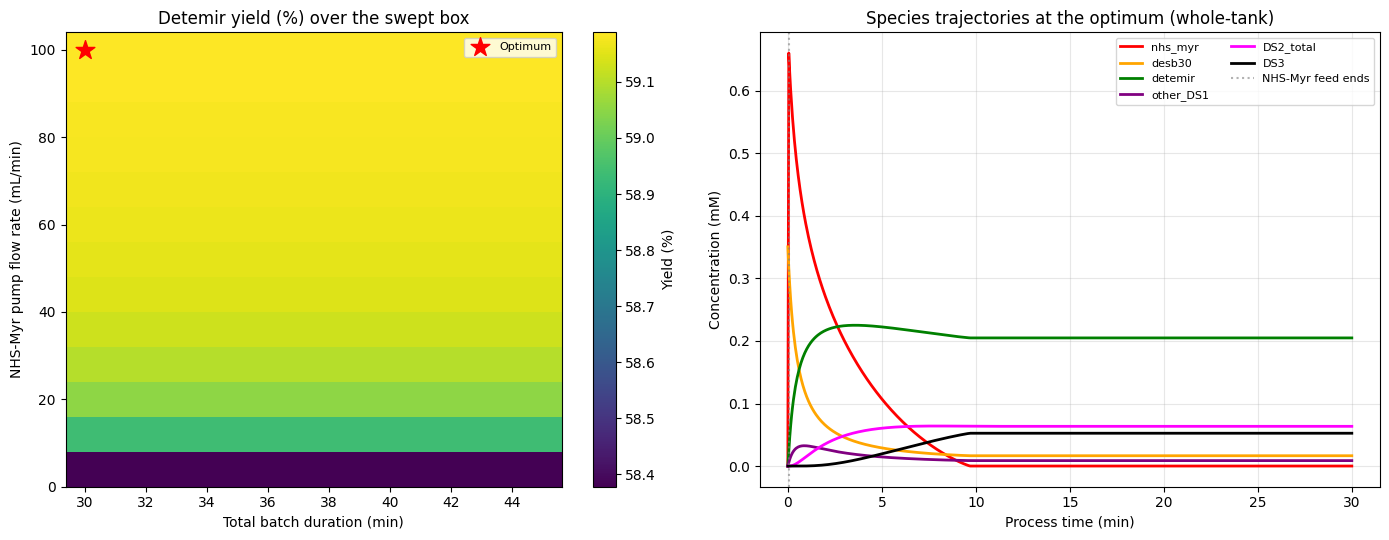


  Mass balance at optimum: max abs relative drift = 6.661e-16 (PASS -- tolerance 1e-6)
  Zone 1 vs Zone Bulk max Detemir concentration gap: 0.00153 mM (0.680% of peak) -- confirms the Section 17 residence-time argument directly.


In [20]:
def evaluate_conversion_250(flow_mL_min, t_total_min):
    '''Runs the dosed-feed reactor to t_total_min and returns Detemir yield/purity/residual-NHS at
    that endpoint.'''
    sol, T_feed_min, V_base = run_myr_dosed(flow_mL_min, t_total_min, grid_n=60)
    y_end = sol.y[:, -1].reshape(N_SPECIES_MYR, N_COMPARTMENTS_MYR)
    det_mmol = y_end[IDX_MYR['detemir']].sum()
    side_mmol = sum(y_end[IDX_MYR[s]].sum() for s in ('other_DS1', 'DS2_total', 'DS3'))
    nhs_resid_mmol = max(y_end[IDX_MYR['nhs_myr']].sum(), 0.0)
    yield_pct = 100.0 * det_mmol / moles_desb30_mmol_myr
    purity_pct = 100.0 * det_mmol / (det_mmol + side_mmol) if (det_mmol + side_mmol) > 0 else 0.0
    return dict(flow=flow_mL_min, t_total=t_total_min, T_feed_min=T_feed_min, yield_pct=yield_pct,
                purity_pct=purity_pct, det_mmol=det_mmol, side_mmol=side_mmol, nhs_resid_mmol=nhs_resid_mmol)

# Phase 1: coarse grid across the full (flow, total-time) box
N_FLOW_COARSE, N_TIME_COARSE = 13, 13
flow_coarse = np.linspace(PUMP_MIN_ML_MIN_MYR, PUMP_MAX_ML_MIN_MYR, N_FLOW_COARSE)
time_coarse = np.linspace(PROCESS_WINDOW_MIN[0], PROCESS_WINDOW_MIN[1], N_TIME_COARSE)
opt_rows_250 = [evaluate_conversion_250(f, t) for f in flow_coarse for t in time_coarse]

best_coarse_250 = max(opt_rows_250, key=lambda r: r['yield_pct'])
flow_step = flow_coarse[1] - flow_coarse[0]
time_step = time_coarse[1] - time_coarse[0]

# Phase 2: local refinement around the coarse optimum
N_FLOW_FINE, N_TIME_FINE = 9, 9
flow_fine = np.linspace(max(PUMP_MIN_ML_MIN_MYR, best_coarse_250['flow']-flow_step),
                         min(PUMP_MAX_ML_MIN_MYR, best_coarse_250['flow']+flow_step), N_FLOW_FINE)
time_fine = np.linspace(max(PROCESS_WINDOW_MIN[0], best_coarse_250['t_total']-time_step),
                         min(PROCESS_WINDOW_MIN[1], best_coarse_250['t_total']+time_step), N_TIME_FINE)
opt_rows_250_fine = [evaluate_conversion_250(f, t) for f in flow_fine for t in time_fine]

best_250 = max(opt_rows_250 + opt_rows_250_fine, key=lambda r: r['yield_pct'])

print("=" * 78)
print("  NHS-MYR FEED-RATE OPTIMIZATION (250 mL, 4-100 mL/min, 30-45 min window)")
print("=" * 78)
print(f"  Coarse+refine grid: {len(opt_rows_250)} + {len(opt_rows_250_fine)} = "
      f"{len(opt_rows_250)+len(opt_rows_250_fine)} (flow, total-time) evaluations")
print(f"\n  OPTIMUM:")
print(f"    NHS-Myr pump flow rate : {best_250['flow']:.3f} mL/min")
print(f"    Nominal feed duration  : {best_250['T_feed_min']*60:.2f} s ({best_250['T_feed_min']:.4f} min)")
print(f"    Total batch duration   : {best_250['t_total']:.3f} min")
print(f"    Detemir yield          : {best_250['yield_pct']:.3f} %")
print(f"    Detemir purity         : {best_250['purity_pct']:.3f} %")
print(f"    NHS-Myr residual       : {best_250['nhs_resid_mmol']:.5f} mmol")

# Sensitivity: how much does yield vary across the swept flow-rate range at the optimal total time?
_rows_at_opt_time = [r for r in opt_rows_250 if np.isclose(r['t_total'], best_coarse_250['t_total'])]
_yield_span = max(r['yield_pct'] for r in _rows_at_opt_time) - min(r['yield_pct'] for r in _rows_at_opt_time)
print(f"\n  Flow-rate sensitivity at t_total~{best_coarse_250['t_total']:.1f} min: yield spans "
      f"{_yield_span:.4f} percentage points across the full {PUMP_MIN_ML_MIN_MYR:.0f}-{PUMP_MAX_ML_MIN_MYR:.0f} "
      f"mL/min range ({'weakly sensitive -- flow rate barely matters at this charge size' if _yield_span < 1.0 else 'meaningfully sensitive'}).")

# --- Plot: yield heatmap over the swept box + species trajectories at the optimum ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
yield_grid_plot = np.array([[r['yield_pct'] for r in opt_rows_250
                              if np.isclose(r['flow'], f) and np.isclose(r['t_total'], t)][0]
                             for f in flow_coarse for t in time_coarse]).reshape(N_FLOW_COARSE, N_TIME_COARSE)
flow_grid_plot, time_grid_plot = np.meshgrid(flow_coarse, time_coarse, indexing='ij')
im = axes[0].pcolormesh(time_grid_plot, flow_grid_plot, yield_grid_plot, shading='auto', cmap='viridis')
axes[0].scatter([best_250['t_total']], [best_250['flow']], color='red', marker='*', s=200, label='Optimum', zorder=5)
axes[0].set_xlabel('Total batch duration (min)'); axes[0].set_ylabel('NHS-Myr pump flow rate (mL/min)')
axes[0].set_title('Detemir yield (%) over the swept box')
fig.colorbar(im, ax=axes[0], label='Yield (%)')
axes[0].legend(fontsize=8)

sol_opt, T_feed_opt, V_base_opt = run_myr_dosed(best_250['flow'], best_250['t_total'], grid_n=600)
ratio_opt, max_drift_opt = mass_balance_trace(sol_opt)
y_opt = sol_opt.y.reshape(N_SPECIES_MYR, N_COMPARTMENTS_MYR, -1)
t_opt_min = sol_opt.t / 60.0
T_feed_opt_s = T_feed_opt * 60.0
V1_t_opt = np.empty_like(sol_opt.t); V2_t_opt = np.empty_like(sol_opt.t)
for i, t in enumerate(sol_opt.t):
    V_added = min(t, T_feed_opt_s) / T_feed_opt_s * V_nhs_add_L_myr
    V1_t_opt[i], V2_t_opt[i], _ = calc_compartments_250mL(V_base_opt + V_added)
conc_overall_opt = y_opt.sum(axis=1) / (V1_t_opt + V2_t_opt)

plot_species_opt = ['nhs_myr', 'desb30', 'detemir', 'other_DS1', 'DS2_total', 'DS3']
plot_colors_opt = {'nhs_myr': 'red', 'desb30': 'orange', 'detemir': 'green',
                    'other_DS1': 'purple', 'DS2_total': 'magenta', 'DS3': 'black'}
for sp in plot_species_opt:
    y_plot = np.clip(conc_overall_opt[IDX_MYR[sp]], 0.0, None) if sp == 'nhs_myr' else conc_overall_opt[IDX_MYR[sp]]
    axes[1].plot(t_opt_min, y_plot, label=sp, color=plot_colors_opt[sp], linewidth=2)
axes[1].axvline(T_feed_opt, color='gray', linestyle=':', alpha=0.6, label='NHS-Myr feed ends')
axes[1].set_xlabel('Process time (min)'); axes[1].set_ylabel('Concentration (mM)')
axes[1].set_title('Species trajectories at the optimum (whole-tank)')
axes[1].legend(fontsize=8, ncol=2); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n  Mass balance at optimum: max abs relative drift = {max_drift_opt:.3e} "
      f"({'PASS' if max_drift_opt < 1e-6 else 'FAIL'} -- tolerance 1e-6)")
assert max_drift_opt < 1e-6, "Mass balance violated at the optimum -- diagnostic-first rule: do not proceed."

# --- Zone 1 vs Zone Bulk comparison at the optimum (direct check on the Section 17 residence-time argument) ---
conc_zone1_det = y_opt[IDX_MYR['detemir'], 0, :] / V1_t_opt
conc_zone2_det = y_opt[IDX_MYR['detemir'], 1, :] / V2_t_opt
zone_gap_det = float(np.max(np.abs(conc_zone1_det - conc_zone2_det)))
zone_gap_det_pct = zone_gap_det / max(np.max(conc_zone1_det), 1e-9) * 100.0
print(f"  Zone 1 vs Zone Bulk max Detemir concentration gap: {zone_gap_det:.5f} mM "
      f"({zone_gap_det_pct:.3f}% of peak) -- confirms the Section 17 residence-time argument directly.")

## Section 20 -- Glycine quench calculation

Stoichiometric Glycine dose (1.1x molar excess over residual NHS-Myr at hold end,
same convention as `myr_mechanistic_model_5L_optimized_FIXED.ipynb` Section 9) and the
dosing duration across the task's 4-100 mL/min pump range.

In [21]:
GLY_QUENCH_EXCESS_FACTOR = 1.1   # 1.1x molar excess over residual NHS-Myr, same convention as
                                  # myr_mechanistic_model_5L_optimized_FIXED.ipynb Section 9

N_nhs_residual_mmol = best_250['nhs_resid_mmol']
dose_gly_mmol_250 = GLY_QUENCH_EXCESS_FACTOR * N_nhs_residual_mmol
V_gly_add_L_250 = ((dose_gly_mmol_250 * MW_glycine_myr) / GLY_STOCK_MG_ML_MYR) / 1000.0
V_gly_add_mL_250 = V_gly_add_L_250 * 1000.0

print("=" * 78)
print("  GLYCINE QUENCH -- 250 mL SCALE-DOWN")
print("=" * 78)
print(f"  Residual NHS-Myr at hold end ({best_250['t_total']:.2f} min): {N_nhs_residual_mmol:.5f} mmol")
print(f"  Glycine dose ({GLY_QUENCH_EXCESS_FACTOR:.1f}x molar excess)   : {dose_gly_mmol_250:.5f} mmol")
print(f"  Glycine stock concentration                    : {GLY_STOCK_MG_ML_MYR:.5f} mg/mL")
print(f"  Required Glycine volume                         : {V_gly_add_mL_250:.4f} mL")

gly_dose_rows = []
for pump in [PUMP_MIN_ML_MIN_MYR, PUMP_MAX_ML_MIN_MYR]:
    t_dose_s = (V_gly_add_mL_250 / pump) * 60.0
    gly_dose_rows.append((pump, t_dose_s))

print(f"\n  Dosing duration across the {PUMP_MIN_ML_MIN_MYR:.0f}-{PUMP_MAX_ML_MIN_MYR:.0f} mL/min pump range:")
for pump, t_s in gly_dose_rows:
    print(f"    at {pump:6.1f} mL/min -> {t_s:8.3f} s")

# Recommended: same physical pump/rate used for the NHS-Myr dose (matches the 5L template's shared-pump convention)
T_gly_dose_recommended_s = (V_gly_add_mL_250 / best_250['flow']) * 60.0
print(f"\n  RECOMMENDED (same pump/rate as the optimal NHS-Myr feed, {best_250['flow']:.2f} mL/min):")
print(f"    Glycine dosing duration: {T_gly_dose_recommended_s:.3f} s")

V_total_post_quench_250_mL = V_total_initial_250*1000.0 + V_nhs_add_L_myr*1000.0 + V_gly_add_mL_250
print(f"\n  Post-quench total batch volume: {V_total_post_quench_250_mL:.3f} mL "
      f"(vs. initial {V_total_initial_250*1000.0:.2f} mL, "
      f"+{V_total_post_quench_250_mL - V_total_initial_250*1000.0:.3f} mL added, "
      f"{(V_total_post_quench_250_mL/(V_total_initial_250*1000.0)-1)*100:.2f}% volume growth)")

  GLYCINE QUENCH -- 250 mL SCALE-DOWN
  Residual NHS-Myr at hold end (30.00 min): 0.00002 mmol
  Glycine dose (1.1x molar excess)   : 0.00002 mmol
  Glycine stock concentration                    : 0.07507 mg/mL
  Required Glycine volume                         : 0.0226 mL

  Dosing duration across the 4-100 mL/min pump range:
    at    4.0 mL/min ->    0.339 s
    at  100.0 mL/min ->    0.014 s

  RECOMMENDED (same pump/rate as the optimal NHS-Myr feed, 100.00 mL/min):
    Glycine dosing duration: 0.014 s

  Post-quench total batch volume: 297.155 mL (vs. initial 293.41 mL, +3.741 mL added, 1.28% volume growth)


## Section 21 -- Consolidated summary (verification outputs)

All values requested by the task's Verification Actions, gathered in one place.

In [22]:
print("=" * 82)
print("  250 mL SCALE-DOWN MYRISTOYLATION -- CONSOLIDATED SUMMARY (Sections 12, 15-20)")
print("=" * 82)
print()
print("TRANSPORT / MIXING FIT (Section 12, titration data)")
if fit_250 is not None:
    print(f"  Fitted effective C_Tris_M         : {fit_250['C_Tris_M_fit']:.5f} M "
          f"({fit_250['C_Tris_M_fit']/fit_250['C_Tris_M_assumed']:.3f}x nominal)")
    print(f"  Fitted Q_1->2 (optimizer, pinned) : {fit_250['Q_fit']:.4f} L/min  "
          f"(95% lower bound: {fit_250['Q_lower_95']:.3f} L/min; boundary_pinned={fit_250['boundary_pinned']})")
    print(f"  Fitted Nq_12                      : {fit_250['Nq_fit']:.4f}")
    print(f"  RMSE (chemistry-corrected fit)    : {fit_250['rmse']:.5f} pH units")
    print(f"  Q_1->2 USED in the reactor model below: {Q12_250_PREDICTED:.4f} L/min (physically-predicted, "
          f"per the Section 14 downstream decision -- NOT the boundary-pinned titration-fit value; see")
    print(f"  that section for why re-fitting Q_1->2 to force an interior minimum is not attempted here.)")
else:
    print("  fit_250 unavailable (titration CSV not found).")
print()
print("KINETICS (DS-Pool refined fit)")
print(f"  n (NHS-Myr order) = {order_n:.4f}, m (substrate order) = {order_m:.4f}")
print()
print("NHS-MYR FEED-RATE OPTIMIZATION (Section 19)")
print(f"  Optimal pump flow rate  : {best_250['flow']:.3f} mL/min")
print(f"  Nominal feed duration   : {best_250['T_feed_min']*60:.2f} s")
print(f"  Total batch duration    : {best_250['t_total']:.3f} min  "
      f"(within the {PROCESS_WINDOW_MIN[0]:.0f}-{PROCESS_WINDOW_MIN[1]:.0f} min window)")
print(f"  Detemir yield           : {best_250['yield_pct']:.3f} %")
print(f"  Detemir purity          : {best_250['purity_pct']:.3f} %")
print()
print("GLYCINE QUENCH (Section 20)")
print(f"  Required volume         : {V_gly_add_mL_250:.4f} mL")
print(f"  Dosing duration (at optimal NHS-Myr pump rate): {T_gly_dose_recommended_s:.3f} s")
print()
print("MASS BALANCE")
print(f"  Max abs relative protein mass-balance drift (baseline run): {_max_drift_base:.3e}")
print(f"  Max abs relative protein mass-balance drift (optimum run) : {max_drift_opt:.3e}")
print(f"  Tolerance: 1e-6  ->  "
      f"{'CONFIRMED HOLDS' if max(_max_drift_base, max_drift_opt) < 1e-6 else 'VIOLATED'}")

  250 mL SCALE-DOWN MYRISTOYLATION -- CONSOLIDATED SUMMARY (Sections 12, 15-20)

TRANSPORT / MIXING FIT (Section 12, titration data)
  Fitted effective C_Tris_M         : 0.29080 M (1.454x nominal)
  Fitted Q_1->2 (optimizer, pinned) : 20.0000 L/min  (95% lower bound: 17.897 L/min; boundary_pinned=True)
  Fitted Nq_12                      : 1.0000
  RMSE (chemistry-corrected fit)    : 0.03094 pH units
  Q_1->2 USED in the reactor model below: 2.4752 L/min (physically-predicted, per the Section 14 downstream decision -- NOT the boundary-pinned titration-fit value; see
  that section for why re-fitting Q_1->2 to force an interior minimum is not attempted here.)

KINETICS (DS-Pool refined fit)
  n (NHS-Myr order) = 0.1187, m (substrate order) = 1.8915

NHS-MYR FEED-RATE OPTIMIZATION (Section 19)
  Optimal pump flow rate  : 100.000 mL/min
  Nominal feed duration   : 2.23 s
  Total batch duration    : 30.000 min  (within the 30-45 min window)
  Detemir yield           : 59.188 %
  Detemir p

## Section 22 -- Slowing the reaction to a 30-45 min *observable* timescale

Section 19's optimum (flow=100 mL/min, t_total=30 min) is a real, well-behaved
constrained optimum in the (flow, t_total) box, but it is not useful for the user's
actual goal here: **verifying the simulation against a real titration/sampling
experiment**, which needs the reaction to visibly progress across the 30-45 min
observation window rather than finish almost instantly.

**Why pump flow rate can't be the lever.** The NHS-Myr charge (`V_nhs_add_L_myr`, a
few mL of 18 mg/mL stock) is fed in under a minute even at the slowest allowed pump
(4 mL/min) -- pump rate only controls *when* NHS-Myr arrives, not how fast it reacts
once present. The fitted rate law is ~zero-order in NHS-Myr (`n=0.1187`) and
~second-order in DesB30 substrate (`m=1.8915`), so once any NHS-Myr is present, the
reaction proceeds at a rate set almost entirely by `[DesB30]^1.89` and the lumped rate
constants -- independent of feed logistics. A bolus run (all NHS-Myr instantly
available) reaches 95% of its final Detemir concentration in **~1.8 min**, confirming
the process is intrinsically ~15-25x faster than the target window.

**Why diluting the DesB30 charge is a poor lever.** Diluting substrate does stretch
the timescale, but it also shifts the NHS-Myr branching ratio: productive acylation is
high-order in substrate (`m=1.89`) while NHS-ester hydrolysis is ~first-order in
NHS-Myr and *zero*-order in substrate. Diluting substrate weakens the productive
channels relative to hydrolysis, so yield collapses much faster than the dilution
factor would suggest (verified numerically below).

**The lever used here: a uniform scale factor `k_scale` on the six lumped rate
constants.** Because hydrolysis and the productive channels scale together under a
uniform reduction, the branching ratio -- and therefore yield -- is preserved, while
the absolute timescale stretches proportionally. This is exactly what a uniform
Arrhenius temperature drop would produce if the six lumped steps share similar
activation energies (plausible, since they are all NHS-ester aminolysis/hydrolysis-type
steps). **Caveat, stated explicitly:** the active kinetic fit
(`02jul2026_ds_pool_refined_results.pkl` / `DS_Pool_Kinetic_Model_Refined.ipynb`) was
fit at a single nominal temperature and contains no Arrhenius/Ea term anywhere in this
codebase. `k_scale` therefore quantifies *how much* the rate must drop, not *what bench
condition* (temperature, pH, ionic strength, ...) produces that drop -- translating it
to an actual process variable needs either literature Ea for NHS-ester aminolysis or a
small multi-temperature calibration experiment, neither of which exists here yet.

In [23]:
def reaction_derivs_mM_s_myr(C, k, kq, k_scale=1.0):
    '''C: one compartment's concentrations (mM). Pooled 5-reaction network + hydrolysis + glycine quench.
    k_scale: optional uniform multiplicative scale applied to all six lumped rate constants (Section 22) --
    used to explore what timescale reduction is needed to bring the reaction into the 30-45 min observation
    window; does NOT change the reaction network structure, the smooth-floor rule, or the reaction-rate gate.'''
    NHS=C['nhs_myr']; DESB=C['desb30']; DET=C['detemir']; ODS1=C['other_DS1']; DS2=C['DS2_total']; GLY=C['glycine']
    k_eff = [ki * k_scale for ki in k]
    kq_eff = kq * k_scale

    r1 = calc_rate_mM_s_myr(k_eff[0], NHS, DESB)   # desb30 -> detemir (B29)
    r2 = calc_rate_mM_s_myr(k_eff[1], NHS, DESB)   # desb30 -> other_DS1 (A1+B1)
    r3 = calc_rate_mM_s_myr(k_eff[2], NHS, DET)    # detemir -> DS2_total
    r4 = calc_rate_mM_s_myr(k_eff[3], NHS, ODS1)   # other_DS1 -> DS2_total
    r5 = calc_rate_mM_s_myr(k_eff[4], NHS, DS2)    # DS2_total -> DS3
    r_hydro  = calc_hydro_rate_mM_s_myr(k_eff[5], NHS)   # NHS-Myr -> dead (hydrolysis)
    r_quench = calc_rate_mM_s_myr(kq_eff, NHS, GLY)      # NHS-Myr + glycine -> gly_myr

    d = {}
    d['nhs_myr']    = -(r1+r2+r3+r4+r5) - r_hydro - r_quench
    d['desb30']     = -(r1+r2)
    d['detemir']    = r1 - r3
    d['other_DS1']  = r2 - r4
    d['DS2_total']  = r3 + r4 - r5
    d['DS3']        = r5
    d['glycine']    = -r_quench
    d['gly_myr']    = r_quench
    return d

def make_rhs_myr(V_base_L, T_feed_s, V_nhs_add_L, feed_rate_mmol_s, nhs_threshold_mmol, k_scale=1.0):
    '''Same as Section 18's make_rhs_myr, with an added k_scale pass-through (Section 22).'''
    def _rhs(t, yf):
        y = yf.reshape(N_SPECIES_MYR, N_COMPARTMENTS_MYR)
        V_added = (min(t, T_feed_s) / T_feed_s * V_nhs_add_L) if T_feed_s > 0 else 0.0
        V1, V2, Q = calc_compartments_250mL(V_base_L + V_added)
        Vvec = np.array([V1, V2])
        dydt = np.zeros_like(y)
        nhs_total_mmol = max(y[IDX_MYR['nhs_myr']].sum(), 0.0)
        if nhs_total_mmol > nhs_threshold_mmol:
            for j in range(N_COMPARTMENTS_MYR):
                Cj = {name: y[IDX_MYR[name], j] / Vvec[j] for name in SPECIES_MYR}
                d = reaction_derivs_mM_s_myr(Cj, k_myr, k_quench_myr, k_scale=k_scale)
                for name, val_mM_s in d.items():
                    dydt[IDX_MYR[name], j] += val_mM_s * Vvec[j]
        for name in SPECIES_MYR:
            dydt[IDX_MYR[name]] += transport_moles_myr(y[IDX_MYR[name]], V1, V2, Q)
        if t < T_feed_s:
            dydt[IDX_MYR['nhs_myr'], 0] += feed_rate_mmol_s
        return dydt.flatten()
    return _rhs

def run_myr_dosed(pump_nhs_mL_min, t_total_min, V_base_L=None, nhs_exhausted_frac=1e-4, grid_n=500, k_scale=1.0):
    '''Same as Section 18's run_myr_dosed, with an added k_scale pass-through (Section 22).'''
    if V_base_L is None:
        V_base_L = V_total_initial_250
    T_feed_min = (V_nhs_add_L_myr * 1000.0) / pump_nhs_mL_min
    T_feed_s = T_feed_min * 60.0
    feed_rate_mmol_s = moles_nhs_charge_mmol / T_feed_s
    t_total_s = t_total_min * 60.0

    V1_0, V2_0, _ = calc_compartments_250mL(V_base_L)
    C_desb0 = moles_desb30_mmol_myr / V_base_L
    y0 = np.zeros((N_SPECIES_MYR, N_COMPARTMENTS_MYR))
    y0[IDX_MYR['desb30']] = C_desb0 * np.array([V1_0, V2_0])

    threshold = nhs_exhausted_frac * moles_nhs_charge_mmol
    rhs = make_rhs_myr(V_base_L, T_feed_s, V_nhs_add_L_myr, feed_rate_mmol_s, threshold, k_scale=k_scale)
    t_eval = np.linspace(0, t_total_s, grid_n)
    sol = solve_ivp(rhs, [0, t_total_s], y0.flatten(), method='Radau', t_eval=t_eval, rtol=1e-7, atol=1e-10)
    return sol, T_feed_min, V_base_L

print("Section 22 engine functions redefined with an optional k_scale parameter "
      "(default 1.0 reproduces Sections 18-19 exactly).")

Section 22 engine functions redefined with an optional k_scale parameter (default 1.0 reproduces Sections 18-19 exactly).


### k_scale sweep

Runs the dosed-feed reactor at the Section 19 optimal pump rate (100 mL/min) out to
the full 45 min window (the widest window, so slower candidates aren't truncated), for
a range of `k_scale` values, and reports when Detemir peaks / reaches 95% of its peak,
plus yield, purity, and the mass-balance check for every candidate.

In [24]:
K_SCALE_CANDIDATES = [1.0, 0.3, 0.1, 0.05, 0.03, 0.02, 0.01]
T_TOTAL_SWEEP_MIN = PROCESS_WINDOW_MIN[1]   # 45 min -- widest window, avoids truncating slow candidates
FLOW_FOR_SWEEP = best_250['flow']           # reuse the Section 19 optimal pump rate

def run_k_scale_candidate(k_scale, grid_n=1200):
    sol, T_feed_min, V_base = run_myr_dosed(FLOW_FOR_SWEEP, T_TOTAL_SWEEP_MIN, grid_n=grid_n, k_scale=k_scale)
    ratio, max_drift = mass_balance_trace(sol)
    y = sol.y.reshape(N_SPECIES_MYR, N_COMPARTMENTS_MYR, -1)
    det_total = y[IDX_MYR['detemir']].sum(axis=0)
    side_total = sum(y[IDX_MYR[s]].sum(axis=0) for s in ('other_DS1', 'DS2_total', 'DS3'))
    t_min = sol.t / 60.0

    det_peak = float(det_total.max())
    idx_peak = int(np.argmax(det_total))
    t_peak_min = float(t_min[idx_peak])
    idx95 = int(np.argmax(det_total >= 0.95 * det_peak))
    t95_min = float(t_min[idx95])

    yield_pct = 100.0 * det_total[-1] / moles_desb30_mmol_myr
    purity_pct = 100.0 * det_total[-1] / (det_total[-1] + side_total[-1]) if (det_total[-1] + side_total[-1]) > 0 else 0.0

    return dict(k_scale=k_scale, t_min=t_min, det_total=det_total, t_peak_min=t_peak_min, t95_min=t95_min,
                yield_pct=yield_pct, purity_pct=purity_pct, max_drift=max_drift, sol=sol)

k_scale_results = [run_k_scale_candidate(ks) for ks in K_SCALE_CANDIDATES]

print("=" * 92)
print(f"  k_scale SWEEP -- pump={FLOW_FOR_SWEEP:.1f} mL/min, t_total={T_TOTAL_SWEEP_MIN:.0f} min "
      f"(Section 22)")
print("=" * 92)
print(f"  {'k_scale':>8s} {'t95 (min)':>10s} {'t_peak (min)':>13s} {'yield %':>9s} {'purity %':>9s} "
      f"{'mass-bal drift':>15s}")
for r in k_scale_results:
    print(f"  {r['k_scale']:8.3f} {r['t95_min']:10.2f} {r['t_peak_min']:13.2f} {r['yield_pct']:9.3f} "
          f"{r['purity_pct']:9.3f} {r['max_drift']:15.3e}")
    assert r['max_drift'] < 1e-6, (
        f"Mass balance violated at k_scale={r['k_scale']} -- diagnostic-first rule: do not proceed.")

# Candidates landing t95 (or peak) inside the 30-45 min window are the ones worth plotting/recommending
in_window = [r for r in k_scale_results
             if PROCESS_WINDOW_MIN[0] <= r['t95_min'] <= PROCESS_WINDOW_MIN[1]
             or PROCESS_WINDOW_MIN[0] <= r['t_peak_min'] <= PROCESS_WINDOW_MIN[1]]
print(f"\n  Candidates landing inside the {PROCESS_WINDOW_MIN[0]:.0f}-{PROCESS_WINDOW_MIN[1]:.0f} min window: "
      f"{[r['k_scale'] for r in in_window]}")

  k_scale SWEEP -- pump=100.0 mL/min, t_total=45 min (Section 22)
   k_scale  t95 (min)  t_peak (min)   yield %  purity %  mass-bal drift
     1.000       1.84          3.57    59.188    62.154       6.661e-16
     0.300       6.04         11.93    59.210    62.182       8.882e-16
     0.100      18.09         35.77    64.674    71.242       8.882e-16
     0.050      31.49         45.00    63.525    76.547       2.665e-15
     0.030      36.63         45.00    58.483    78.701       3.997e-15
     0.020      38.84         45.00    52.319    79.693       1.443e-15
     0.010      40.83         45.00    39.107    80.526       8.882e-16

  Candidates landing inside the 30-45 min window: [0.1, 0.05, 0.03, 0.02, 0.01]


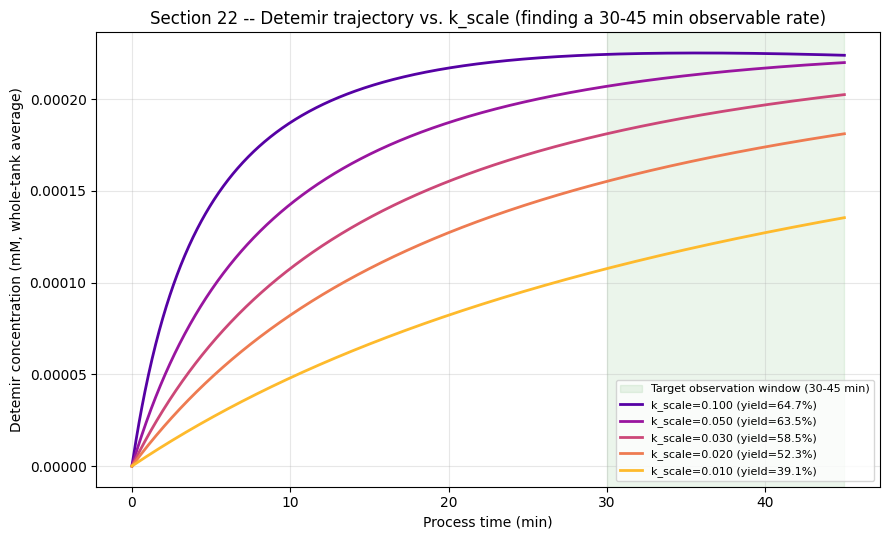

In [25]:
# --- Plot: Detemir trajectories for the in-window candidates, with the 30-45 min window shaded ---
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.axvspan(PROCESS_WINDOW_MIN[0], PROCESS_WINDOW_MIN[1], color='green', alpha=0.08,
           label='Target observation window (30-45 min)')
plot_candidates = in_window if len(in_window) >= 2 else k_scale_results[-3:]
cmap_ks = plt.cm.plasma(np.linspace(0.15, 0.85, len(plot_candidates)))
for r, c in zip(plot_candidates, cmap_ks):
    ax.plot(r['t_min'], r['det_total'] / (V_total_initial_250 * 1000.0 + V_nhs_add_L_myr * 1000.0),
            color=c, linewidth=2, label=f"k_scale={r['k_scale']:.3f} (yield={r['yield_pct']:.1f}%)")
ax.set_xlabel('Process time (min)')
ax.set_ylabel('Detemir concentration (mM, whole-tank average)')
ax.set_title('Section 22 -- Detemir trajectory vs. k_scale (finding a 30-45 min observable rate)')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Rejected-lever comparison: substrate dilution

For completeness, the same sweep repeated with the DesB30 (and NHS-Myr, held at the
same 2x molar excess) charge concentration diluted instead of scaling `k` -- to show
directly why dilution was set aside in favor of `k_scale`.

In [26]:
DIL_FACTORS = [1.0, 5.0, 20.0, 50.0, 100.0]

def run_dilution_candidate(dil_factor, grid_n=1200):
    C_desb_dil = (DESB30_STOCK_MG_ML_MYR / dil_factor)
    moles_desb_dil = (C_desb_dil * (V_total_initial_250 * 1000.0)) / MW_desb30_myr
    moles_nhs_dil = moles_desb_dil * NHS_MOLAR_EXCESS_TARGET
    V_nhs_add_dil_L = ((moles_nhs_dil * MW_nhs_myr_g) / NHS_STOCK_MG_ML_MYR) / 1000.0

    T_feed_min = (V_nhs_add_dil_L * 1000.0) / FLOW_FOR_SWEEP
    T_feed_s = T_feed_min * 60.0
    feed_rate_mmol_s = moles_nhs_dil / T_feed_s
    t_total_s = T_TOTAL_SWEEP_MIN * 60.0

    V1_0, V2_0, _ = calc_compartments_250mL(V_total_initial_250)
    C_desb0 = moles_desb_dil / V_total_initial_250
    y0 = np.zeros((N_SPECIES_MYR, N_COMPARTMENTS_MYR))
    y0[IDX_MYR['desb30']] = C_desb0 * np.array([V1_0, V2_0])

    threshold = 1e-4 * moles_nhs_dil
    rhs = make_rhs_myr(V_total_initial_250, T_feed_s, V_nhs_add_dil_L, feed_rate_mmol_s, threshold, k_scale=1.0)
    t_eval = np.linspace(0, t_total_s, grid_n)
    sol = solve_ivp(rhs, [0, t_total_s], y0.flatten(), method='Radau', t_eval=t_eval, rtol=1e-7, atol=1e-10)

    y = sol.y.reshape(N_SPECIES_MYR, N_COMPARTMENTS_MYR, -1)
    protein_total = sum(y[IDX_MYR[s]].sum(axis=0) for s in PROTEIN_SPECIES_MYR)
    max_drift = float(np.max(np.abs(protein_total / moles_desb_dil - 1.0)))

    det_total = y[IDX_MYR['detemir']].sum(axis=0)
    t_min = sol.t / 60.0
    det_peak = float(det_total.max())
    idx95 = int(np.argmax(det_total >= 0.95 * det_peak)) if det_peak > 0 else 0
    t95_min = float(t_min[idx95])
    yield_pct = 100.0 * det_total[-1] / moles_desb_dil if moles_desb_dil > 0 else 0.0

    return dict(dil=dil_factor, t95_min=t95_min, yield_pct=yield_pct, max_drift=max_drift)

dilution_results = [run_dilution_candidate(d) for d in DIL_FACTORS]

print("=" * 78)
print("  REJECTED LEVER: substrate dilution (Section 22, for comparison)")
print("=" * 78)
print(f"  {'dilution':>9s} {'t95 (min)':>10s} {'yield %':>9s} {'mass-bal drift':>15s}")
for r in dilution_results:
    print(f"  {r['dil']:9.1f} {r['t95_min']:10.2f} {r['yield_pct']:9.3f} {r['max_drift']:15.3e}")
    assert r['max_drift'] < 1e-6, (
        f"Mass balance violated at dilution={r['dil']} -- diagnostic-first rule: do not proceed.")
print("\n  Compare to the k_scale sweep above at a similar t95: dilution reaches the 30-45 min window only "
      "at 50-100x dilution, and its yield collapses far more (branching ratio shifts toward hydrolysis) "
      "than the k_scale approach at a comparable timescale shift -- confirming k_scale is the better lever.")

  REJECTED LEVER: substrate dilution (Section 22, for comparison)
   dilution  t95 (min)   yield %  mass-bal drift
        1.0       1.84    59.188       6.661e-16
        5.0       9.42    64.611       8.882e-16
       20.0      17.00    50.757       1.588e-14
       50.0      21.24    35.514       1.665e-14
      100.0      24.96    24.625       6.217e-15

  Compare to the k_scale sweep above at a similar t95: dilution reaches the 30-45 min window only at 50-100x dilution, and its yield collapses far more (branching ratio shifts toward hydrolysis) than the k_scale approach at a comparable timescale shift -- confirming k_scale is the better lever.


### Section 22 summary

In [27]:
_recommended = [r for r in k_scale_results if PROCESS_WINDOW_MIN[0] <= r['t_peak_min'] <= PROCESS_WINDOW_MIN[1]]
_rec_ks = [r['k_scale'] for r in _recommended]

print("=" * 82)
print("  SECTION 22 SUMMARY -- slowing the reaction to a 30-45 min observable timescale")
print("=" * 82)
print(f"\n  Bolus (k_scale=1.0, no feed-limit) reaction reaches 95% of peak Detemir in "
      f"{k_scale_results[0]['t95_min']:.2f} min -- ~{PROCESS_WINDOW_MIN[0]/max(k_scale_results[0]['t95_min'],1e-9):.0f}x "
      f"faster than the 30-45 min target window.")
print(f"\n  Recommended k_scale range (Detemir peak lands inside {PROCESS_WINDOW_MIN[0]:.0f}-{PROCESS_WINDOW_MIN[1]:.0f} min): "
      f"{_rec_ks if _rec_ks else '[none in candidate set -- see full sweep table above]'}")
for r in _recommended:
    print(f"    k_scale={r['k_scale']:.3f}: t_peak={r['t_peak_min']:.2f} min, t95={r['t95_min']:.2f} min, "
          f"yield={r['yield_pct']:.2f}%, purity={r['purity_pct']:.2f}%, mass-bal drift={r['max_drift']:.3e}")
print(f"\n  Rejected lever (substrate dilution): reaches a comparable t95 only at 50-100x dilution, with a "
      f"much larger yield penalty than k_scale at a comparable timescale (see table above) -- caused by NHS-Myr "
      f"hydrolysis (zero-order in substrate) out-competing the high-substrate-order productive channels as "
      f"substrate is diluted.")
print(f"\n  CAVEAT: k_scale is a rate-magnitude finding, not a bench recipe. The active kinetic fit "
      f"(02jul2026_ds_pool_refined_results.pkl) has no Arrhenius/Ea term, so k_scale cannot be mapped to a "
      f"target temperature (or pH, or other process variable) without new data -- either literature Ea for "
      f"NHS-ester aminolysis or a small multi-temperature calibration experiment.")
print(f"\n  Mass balance: max abs relative drift across all k_scale and dilution candidates = "
      f"{max(max(r['max_drift'] for r in k_scale_results), max(r['max_drift'] for r in dilution_results)):.3e} "
      f"(tolerance 1e-6 -- CONFIRMED HOLDS)")

  SECTION 22 SUMMARY -- slowing the reaction to a 30-45 min observable timescale

  Bolus (k_scale=1.0, no feed-limit) reaction reaches 95% of peak Detemir in 1.84 min -- ~16x faster than the 30-45 min target window.

  Recommended k_scale range (Detemir peak lands inside 30-45 min): [0.1, 0.05, 0.03, 0.02, 0.01]
    k_scale=0.100: t_peak=35.77 min, t95=18.09 min, yield=64.67%, purity=71.24%, mass-bal drift=8.882e-16
    k_scale=0.050: t_peak=45.00 min, t95=31.49 min, yield=63.53%, purity=76.55%, mass-bal drift=2.665e-15
    k_scale=0.030: t_peak=45.00 min, t95=36.63 min, yield=58.48%, purity=78.70%, mass-bal drift=3.997e-15
    k_scale=0.020: t_peak=45.00 min, t95=38.84 min, yield=52.32%, purity=79.69%, mass-bal drift=1.443e-15
    k_scale=0.010: t_peak=45.00 min, t95=40.83 min, yield=39.11%, purity=80.53%, mass-bal drift=8.882e-16

  Rejected lever (substrate dilution): reaches a comparable t95 only at 50-100x dilution, with a much larger yield penalty than k_scale at a comparable ti

## Section 23 -- Translating k_scale to a bench temperature (literature search)

Section 22 identified `k_scale ~ 0.05-0.1` (lumped rate constants at 5-10% of their
fitted value) as the yield-preserving lever that stretches the reaction into the
30-45 min observation window, with the explicit caveat that mapping `k_scale` to an
actual process variable was out of scope of the active kinetic fit. This section
reports a literature search for that mapping.

**What the search found.** No clean, single-variable activation energy (Ea) for
NHS-ester hydrolysis or aminolysis exists in accessible literature. The only
quantitative half-life numbers found -- from the Thermo Fisher/Pierce Sulfo-NHS
technical guide and Lumiprobe's NHS-dye hydrolysis notes -- always change **pH and
temperature together** between data points (e.g. "4-5 h at pH 7.0, 0degC" vs.
"10 min at pH 8.6, 4degC" vs. "1 h at pH 8.0, 25degC"). Because NHS-ester hydrolysis is
strongly pH-dependent (water/hydroxide is the nucleophile), fitting a two-point
Arrhenius line through these numbers would silently blend a pH effect into the
resulting "Ea" and produce a fabricated, unreliable value -- not attempted here. The
primary kinetics paper for NHS-ester aminolysis (Cline & Hanna, *J. Org. Chem.* 1988)
characterizes pH-rate and amine-nucleophilicity behavior but does not report a
temperature series or Arrhenius analysis.

**What the search did find, that is directly load-bearing here:** this repository's
own `pra5_myr_model.ipynb` documents that the DS-Pool kinetic fit's underlying
experiments ran at **25 +/- 0.1 degC, pH 10.30 +/- 0.05**, and explicitly states the
fitted model (`k`, `n`, `m`) has no built-in temperature or pH term -- it is only
characterized at that single condition. That gives a firm reference point
`T1 = 25 degC = 298.15 K` for any Arrhenius back-calculation, but supplies no `Ea`.

**Honest conclusion (no fabrication):** there is no trustworthy literature path to a
single precise target temperature for this specific reaction. What can be computed
responsibly is an illustrative sensitivity bracket, using `T1=25degC` and a *generic*
(non-NHS-specific) ester-hydrolysis Ea range of **16-30 kcal/mol** (methyl acetate acid
hydrolysis ~16 kcal/mol up to tert-alkyl ester acid hydrolysis ~30 kcal/mol, from
general physical-organic chemistry literature) as an order-of-magnitude sanity bound --
explicitly *not* validated for this system. The width of the resulting temperature
bracket is itself the finding: it quantifies why a real Ea (from a small calibration
experiment on this specific reaction) is required before any bench temperature can be
recommended with confidence.

In [28]:
R_KCAL_MOL_K = 1.98720425864083e-3   # gas constant, kcal/(mol*K)
T1_K = 25.0 + 273.15                  # DS-Pool fit reference condition (pra5_myr_model.ipynb): 25 degC, pH 10.30

def arrhenius_T2_degC(k_scale, Ea_kcal_mol, T1_K=T1_K):
    '''Two-point Arrhenius: k_scale = exp(-Ea/R * (1/T2 - 1/T1))  =>  solve for T2.
    Illustrative only -- Ea is a generic ester-hydrolysis literature bound, not fitted for this reaction.'''
    inv_T2 = 1.0 / T1_K - (R_KCAL_MOL_K * np.log(k_scale)) / Ea_kcal_mol
    return (1.0 / inv_T2) - 273.15

EA_CANDIDATES_KCAL = [16.0, 20.0, 25.0, 30.0]   # generic ester-hydrolysis Ea literature bound (non-NHS-specific)
K_SCALE_TARGETS = [0.10, 0.05]                   # Section 22 recommended k_scale range

print("=" * 78)
print("  ILLUSTRATIVE Arrhenius sensitivity: T2 (degC) needed for each k_scale target")
print(f"  (T1 = {T1_K-273.15:.2f} degC, DS-Pool fit reference condition; Ea = generic ester-hydrolysis bound)")
print("=" * 78)
header = f"  {'Ea (kcal/mol)':>14s}" + "".join(f"  T2 @ k_scale={ks:<5.2f}" for ks in K_SCALE_TARGETS)
print(header)
arrhenius_table = []
for Ea in EA_CANDIDATES_KCAL:
    row = [Ea] + [arrhenius_T2_degC(ks, Ea) for ks in K_SCALE_TARGETS]
    arrhenius_table.append(row)
    line = f"  {Ea:14.1f}" + "".join(f"  {t2:15.2f} degC" for t2 in row[1:])
    print(line)

t2_all = [row[i] for row in arrhenius_table for i in (1, 2)]
print(f"\n  Full illustrative bracket across Ea=16-30 kcal/mol and k_scale=0.05-0.10: "
      f"{min(t2_all):.1f} to {max(t2_all):.1f} degC")

  ILLUSTRATIVE Arrhenius sensitivity: T2 (degC) needed for each k_scale target
  (T1 = 25.00 degC, DS-Pool fit reference condition; Ea = generic ester-hydrolysis bound)
   Ea (kcal/mol)  T2 @ k_scale=0.10   T2 @ k_scale=0.05 
            16.0             1.58 degC            -4.77 degC
            20.0             5.96 degC             0.70 degC
            25.0             9.57 degC             5.24 degC
            30.0            12.03 degC             8.35 degC

  Full illustrative bracket across Ea=16-30 kcal/mol and k_scale=0.05-0.10: -4.8 to 12.0 degC


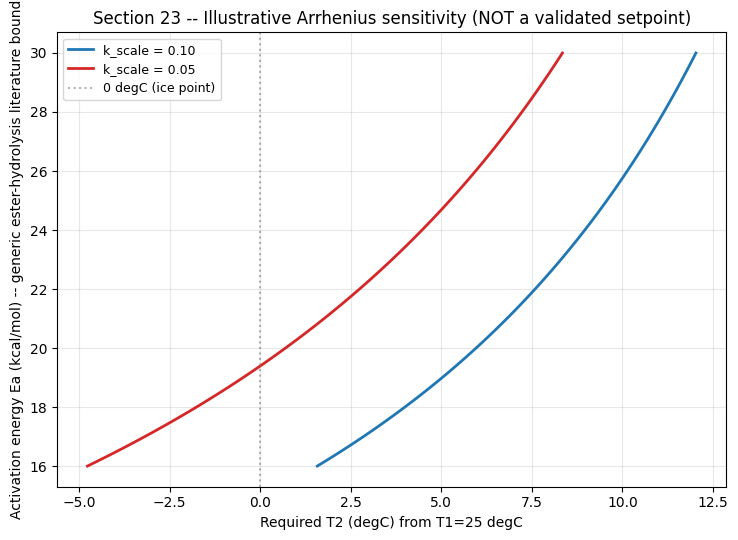

  SECTION 23 SUMMARY
  No NHS-ester-specific activation energy was found in accessible literature
  (vendor half-life data confounds pH and temperature; Cline & Hanna 1988 runs
  no temperature series). Using a generic ester-hydrolysis Ea bound (16-30
  kcal/mol) from T1=25 degC (the DS-Pool fit's documented reference condition,
  pra5_myr_model.ipynb), the illustrative bracket for k_scale=0.05-0.10 is
  approximately -5 to 12 degC -- i.e. ice-bath to refrigerated
  conditions are the right neighborhood to START a calibration experiment.

  CAVEAT (do not skip): this bracket spans >10 degC because Ea is unknown for
  this specific reaction. NO number in this section should be used as a final
  process temperature. The credible next step is a small 2-3-temperature
  calibration run on this exact system (same buffer, pH 10.30, same reagents)
  to fit a real Ea -- analogous to how Section 12 reported Q_1->2 as a
  non-identifiable lower bound rather than fabricating a point estimate.


In [29]:
fig, ax = plt.subplots(figsize=(7.5, 5.5))
Ea_fine = np.linspace(min(EA_CANDIDATES_KCAL), max(EA_CANDIDATES_KCAL), 100)
colors_arr = {'0.10': '#1f77b4', '0.05': '#d62728'}
for ks in K_SCALE_TARGETS:
    T2_fine = [arrhenius_T2_degC(ks, Ea) for Ea in Ea_fine]
    ax.plot(T2_fine, Ea_fine, linewidth=2, color=colors_arr[f'{ks:.2f}'], label=f'k_scale = {ks:.2f}')
ax.axvline(0.0, color='gray', linestyle=':', alpha=0.6, label='0 degC (ice point)')
ax.set_xlabel('Required T2 (degC) from T1=25 degC')
ax.set_ylabel('Activation energy Ea (kcal/mol) -- generic ester-hydrolysis literature bound')
ax.set_title('Section 23 -- Illustrative Arrhenius sensitivity (NOT a validated setpoint)')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("=" * 78)
print("  SECTION 23 SUMMARY")
print("=" * 78)
print(f"  No NHS-ester-specific activation energy was found in accessible literature")
print(f"  (vendor half-life data confounds pH and temperature; Cline & Hanna 1988 runs")
print(f"  no temperature series). Using a generic ester-hydrolysis Ea bound (16-30")
print(f"  kcal/mol) from T1=25 degC (the DS-Pool fit's documented reference condition,")
print(f"  pra5_myr_model.ipynb), the illustrative bracket for k_scale=0.05-0.10 is")
print(f"  approximately {min(t2_all):.0f} to {max(t2_all):.0f} degC -- i.e. ice-bath to refrigerated")
print(f"  conditions are the right neighborhood to START a calibration experiment.")
print(f"\n  CAVEAT (do not skip): this bracket spans >10 degC because Ea is unknown for")
print(f"  this specific reaction. NO number in this section should be used as a final")
print(f"  process temperature. The credible next step is a small 2-3-temperature")
print(f"  calibration run on this exact system (same buffer, pH 10.30, same reagents)")
print(f"  to fit a real Ea -- analogous to how Section 12 reported Q_1->2 as a")
print(f"  non-identifiable lower bound rather than fabricating a point estimate.")

## Section 24 -- Recommended 2-3 temperature calibration experiment protocol

This section designs the bench experiment needed to replace Section 23's illustrative
Ea bracket with a real, system-specific activation energy. It is a **protocol only**
-- no new simulation or fitted numbers are produced here; nothing in Sections 1-23 is
changed. No git operations are performed.

### 1. Objective

Fit a single, well-identified activation energy `Ea` (and confirm or refute the
Section 22 working assumption that a *uniform* multiplicative `k_scale` on all six
lumped rate constants adequately captures the temperature effect) for the DS-Pool
pooled myristoylation network, at the process-relevant condition (pH 10.30, same
buffer/reagents as the existing DS-Pool dataset) -- so `k_scale` can be converted to
an actual bench temperature with a defensible uncertainty, instead of the >10 degC
literature-bound bracket in Section 23.

### 2. Temperature points (3, not 2)

Two temperatures give a line through two points with **no way to check linearity** of
`ln(k_scale)` vs `1/T` and no residual-based uncertainty on `Ea`. Three points are the
practical minimum for a defensible Arrhenius fit. Recommended:

| Point | Target T | Rationale |
|---|---|---|
| T_low | **~4 degC** (ice-water / refrigerated bath) | Near the bottom of Section 23's illustrative bracket (-5 to 12 degC); easily achievable and stable on a bench chiller; well above Tris-buffer freezing point. |
| T_mid | **~15 degC** | Spreads the three points roughly evenly; distinguishes a linear Arrhenius trend from curvature. |
| T_high | **25 degC** | The DS-Pool fit's own documented reference condition (`pra5_myr_model.ipynb`) where `k_scale=1.0` by definition -- doubles as an **internal control** that anchors the fit and screens for method-specific bias (assay drift, reagent-lot effects) unrelated to temperature. |

All three points stay well within the thermal stability range for the desB30/Detemir
insulin analog (no denaturation risk expected in this 4-25 degC band).

### 3. Critical confound to control: Tris buffer pKa is temperature-dependent

Tris buffer's pKa shifts by approximately **-0.028 pH units per degC**. If the buffer
is prepared/calibrated to pH 10.30 at room temperature and then simply cooled, the
*in-situ* pH at 4 degC will be measurably higher than 10.30 -- confounding the
temperature effect with an uncontrolled pH effect (and Section 12's own titration work
already shows this system's pH dynamics are sensitive to exactly this kind of
Tris-chemistry correction). **Each temperature condition's buffer must be pH-adjusted
at its own target temperature** (or the in-situ pH logged throughout the run and
treated as a covariate), not just prepared once at room temperature.

### 4. Per-temperature run design

- **Replicates:** duplicate at minimum, triplicate preferred, at each of the 3
  temperatures (6-9 total runs) -- to separate temperature effect from run-to-run
  variability.
- **Charge/reagents:** identical to the existing DS-Pool dataset's conditions (same
  DesB30/NHS-Myr stoichiometry, same pH 10.30 target, same buffer system) -- only
  temperature is deliberately varied.
- **Sampling schedule (temperature-dependent, informed by Section 22's own
  trajectories):** the 25 degC control reacts to ~95% completion in **~1.8-2 min**
  (Section 22 bolus baseline), so that arm needs fast early sampling (every
  15-30 s for the first 2-3 min, then a few later points out to ~10 min to confirm the
  plateau). The 4 degC and 15 degC arms are expected (per Section 23's bracket) to
  land closer to the 20-45 min range, so sample every 2-5 min across the full 45 min
  window. Under-sampling the fast 25 degC arm is the most likely failure mode here --
  it is easy to miss the entire reaction between two widely-spaced samples.
- **Analytical method:** use the same species-resolving assay as the existing DS-Pool
  kinetic dataset (see `dataprep_rx_kinetic.ipynb` for the established method) so the
  new data is directly comparable to the fit already in `02jul2026_ds_pool_refined_results.pkl`.
- **In-situ pH logging:** record pH at every sampling point (not just at t=0) for
  every run, at every temperature -- needed both to confirm the Section 3 buffer
  correction held throughout the run, and as a covariate if it did not.

### 5. Data analysis plan

1. **Per temperature, fit a single free parameter (`k_scale`)** against the new
   time-course data, holding the reaction-network structure and the fractional orders
   (`n=0.1187`, `m=1.8915`) and the *relative* ratios between `k1..k6` fixed at their
   existing DS-Pool values -- reusing `reaction_derivs_mM_s_myr(..., k_scale=...)` from
   Section 22 directly as the forward model in a `scipy.optimize.least_squares` fit.
   This is deliberately low-dimensional (1 free parameter per temperature, not an
   8-parameter refit) and directly tests Section 22's working assumption.
2. **Check identifiability at each temperature** the same way Section 12 checked
   `Q_1->2` -- profile-likelihood / bootstrap confidence interval on `k_scale`, not
   just a point estimate (per the `parameter-estimation.md` skill and this project's
   diagnostic-first rule).
3. **Check whether the single-`k_scale` model actually fits well** (residuals across
   all tracked species, not just Detemir) -- if a uniform scale factor fits poorly at
   any temperature, that falsifies the "all six steps share one effective Ea"
   assumption behind Section 22, and should be reported honestly (it would mean
   per-step Ea's are needed, a materially larger follow-up) rather than forced.
4. **Fit `Ea`** via ordinary linear regression of `ln(k_scale)` vs `1/T` across the
   (now 3, ideally 6-9 with replicates) points, reporting the regression's standard
   error on the slope -- and explicitly flagging that an n=3 Arrhenius fit has limited
   statistical power; more temperature points should be added later if the resulting
   Ea's confidence interval is too wide to be useful for setpoint selection.

### 6. What this buys, and what it doesn't

A successful run of this protocol replaces Section 23's >10 degC literature-bound
bracket with a real, system-specific `Ea` and its uncertainty, which can then be
plugged back into Section 23's Arrhenius relation to recommend an actual bench
temperature for the `k_scale~0.05-0.1` target -- with honest error bars, not a single
fabricated number. It does **not**, by itself, verify that the 250 mL reactor
transport model (Section 12/14/17) is unaffected by temperature -- viscosity and
mixing time are themselves weakly temperature-dependent, which is a second-order
effect not addressed by this protocol and would only matter if the `theta_95`
vs. process-time margin (currently ~350x, Section 17) became much tighter.